In [1]:
# ── Repo-root navigation ─────────────────────────────────────────────────────
# Ensures relative paths (parquet files, cache dirs, figures) resolve correctly
# whether the notebook is run interactively from notebooks/layerN/ or via
# nbconvert from the project root.
import os
from pathlib import Path
_MARKERS = ["fomc_features.parquet", "fomc_corpus_expanded.parquet", ".git"]
_cwd = Path.cwd()
_root = _cwd
while _root != _root.parent:
    if any((_root / m).exists() for m in _MARKERS):
        break
    _root = _root.parent
if _root != _cwd:
    os.chdir(_root)
    print(f"Working directory → {_root}")
else:
    print(f"Working directory  : {_cwd}")

Working directory → /Users/zinuoshi/fomc-vol-study-repo


In [2]:

from __future__ import annotations

import re
import time
import hashlib
import warnings
import textwrap
from pathlib import Path
from datetime import date, datetime, timedelta
from typing import Optional

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats as sp_stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Configurable params ───────────────────────────────────────────────────────
CACHE_DIR      = Path("fomc_cache")
PARQUET_OUT    = Path("fomc_features.parquet")
START_YEAR     = 2010
END_YEAR       = datetime.today().year
RV_WINDOWS     = [1, 5, 10]        # forward RV horizons in trading days
TFIDF_WINDOW   = 4                 # trailing meetings for novelty centroid
BREVITY_WINDOW = 4                 # trailing meetings for word-count z-score
RATE_LIMIT_S   = 1.5               # seconds between Fed website requests
REGIME_CSV     = Path("fomc_regime.csv")   # optional — see Layer 3

CACHE_DIR.mkdir(exist_ok=True)
(CACHE_DIR / "html").mkdir(exist_ok=True)
(CACHE_DIR / "market").mkdir(exist_ok=True)

print(f"Cache : {CACHE_DIR.resolve()}")
print(f"Out   : {PARQUET_OUT.resolve()}")

Cache : /Users/zinuoshi/fomc-vol-study-repo/fomc_cache
Out   : /Users/zinuoshi/fomc-vol-study-repo/fomc_features.parquet


---
# LAYER 1 — ACQUISITION: FOMC TEXT + MEETING CALENDAR

In [3]:

# Statement release dates (last day of each scheduled/emergency meeting).
# Source: https://www.federalreserve.gov/monetarypolicy/fomchistorical{YEAR}.htm
#         https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm
# Emergency meetings (Mar 2020) are included; presser_available is flagged separately.

_HARDCODED_DATES: list[str] = [
    # 2010
    "2010-01-27","2010-03-16","2010-04-28","2010-06-23",
    "2010-08-10","2010-09-21","2010-11-03","2010-12-14",
    # 2011
    "2011-01-26","2011-03-15","2011-04-27","2011-06-22",
    "2011-08-09","2011-09-21","2011-11-02","2011-12-13",
    # 2012
    "2012-01-25","2012-03-13","2012-04-25","2012-06-20",
    "2012-08-01","2012-09-13","2012-10-24","2012-12-12",
    # 2013
    "2013-01-30","2013-03-20","2013-05-01","2013-06-19",
    "2013-07-31","2013-09-18","2013-10-30","2013-12-18",
    # 2014
    "2014-01-29","2014-03-19","2014-04-30","2014-06-18",
    "2014-07-30","2014-09-17","2014-10-29","2014-12-17",
    # 2015
    "2015-01-28","2015-03-18","2015-04-29","2015-06-17",
    "2015-07-29","2015-09-17","2015-10-28","2015-12-16",
    # 2016
    "2016-01-27","2016-03-16","2016-04-27","2016-06-15",
    "2016-07-27","2016-09-21","2016-11-02","2016-12-14",
    # 2017
    "2017-02-01","2017-03-15","2017-05-03","2017-06-14",
    "2017-07-26","2017-09-20","2017-11-01","2017-12-13",
    # 2018
    "2018-01-31","2018-03-21","2018-05-02","2018-06-13",
    "2018-08-01","2018-09-26","2018-11-08","2018-12-19",
    # 2019
    "2019-01-30","2019-03-20","2019-05-01","2019-06-19",
    "2019-07-31","2019-09-18","2019-10-30","2019-12-11",
    # 2020 (two emergency intermeeting actions: Mar 3 and Mar 15)
    "2020-01-29","2020-03-03","2020-03-15","2020-04-29",
    "2020-06-10","2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    # 2021
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16",
    "2021-07-28","2021-09-22","2021-11-03","2021-12-15",
    # 2022
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15",
    "2022-07-27","2022-09-21","2022-11-02","2022-12-14",
    # 2023
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14",
    "2023-07-26","2023-09-20","2023-11-01","2023-12-13",
    # 2024
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12",
    "2024-07-31","2024-09-18","2024-11-07","2024-12-18",
    # 2025 — verify at https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm
    "2025-01-29","2025-03-19","2025-05-07","2025-06-18",
    "2025-07-30","2025-09-17","2025-10-29","2025-12-10",
    # 2026 (stub — scrape or update manually)
    "2026-01-28","2026-03-18","2026-04-29","2026-06-17",
]

# Chair assignment — update the Warsh start date to the confirmed confirmation date.
_CHAIR_PERIODS: list[tuple[date, date, str]] = [
    (date(2010, 1,  1), date(2014, 1, 31), "Bernanke"),
    (date(2014, 2,  1), date(2018, 2,  2), "Yellen"),
    (date(2018, 2,  3), date(2026, 6, 16), "Powell"),
    (date(2026, 6, 17), date(2030, 1,  1), "Warsh"),
]

# Press conferences: quarterly Apr 2011–Dec 2018; every meeting Jan 2019+.
# Emergency intermeeting actions never have a press conference.
_QUARTERLY_PRESSER_MONTHS = {1, 4, 6, 9, 12}   # approximate quarterly schedule


def _assign_chair(d: date) -> str:
    for start, end, name in _CHAIR_PERIODS:
        if start <= d <= end:
            return name
    return "Unknown"


def _has_presser(d: date, is_emergency: bool = False) -> bool:
    if is_emergency:
        return False
    if d >= date(2019, 1, 1):
        return True
    # Quarterly Apr 2011 – Dec 2018: press conf in Jan/Apr/Jun/Sep/Dec approximately
    if date(2011, 4, 1) <= d <= date(2018, 12, 31):
        return d.month in _QUARTERLY_PRESSER_MONTHS
    return False


def build_fomc_calendar() -> pd.DataFrame:
    """
    Build a DataFrame of FOMC statement release dates with chair and presser flag.
    Returns one row per meeting with columns:
        meeting_date (date), chair (str), presser_available (bool)
    """
    rows = []
    for ds in _HARDCODED_DATES:
        d = datetime.strptime(ds, "%Y-%m-%d").date()
        if d.year < START_YEAR or d.year > END_YEAR:
            continue
        rows.append({
            "meeting_date":      d,
            "chair":             _assign_chair(d),
            "presser_available": _has_presser(d),
        })
    cal = pd.DataFrame(rows).sort_values("meeting_date").reset_index(drop=True)
    print(f"Calendar: {len(cal)} meetings  {cal.meeting_date.min()} → {cal.meeting_date.max()}")
    print(cal.groupby("chair").size().to_string())
    return cal


calendar_df = build_fomc_calendar()

Calendar: 133 meetings  2010-01-27 → 2026-06-17
chair
Bernanke    33
Powell      67
Warsh        1
Yellen      32


In [4]:

_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.5",
}


def fetch_url(url: str, *, delay: float = RATE_LIMIT_S,
              timeout: int = 20) -> Optional[str]:
    """
    Fetch URL with disk cache (keyed by URL hash).  Returns HTML string or
    None if the request fails.  Cached responses skip the delay.
    """
    key  = hashlib.md5(url.encode()).hexdigest()[:16]
    path = CACHE_DIR / "html" / f"{key}.html"

    if path.exists():
        return path.read_text(encoding="utf-8", errors="replace")

    time.sleep(delay)
    try:
        r = requests.get(url, headers=_HEADERS, timeout=timeout)
        r.raise_for_status()
        html = r.text
        path.write_text(html, encoding="utf-8")
        return html
    except requests.RequestException as exc:
        print(f"  FETCH FAILED  {url}\n  {exc}")
        return None

In [5]:

FED_BASE         = "https://www.federalreserve.gov"
STATEMENT_URL_T  = FED_BASE + "/newsevents/pressreleases/monetary{date}a.htm"
PRESSCONF_URL_T  = FED_BASE + "/monetarypolicy/fomcpresconf{date}.htm"


def _extract_statement_text(html: str) -> tuple[str, str]:
    """
    Parse Fed statement HTML.  Returns (raw_text, cleaned_text).
    Strips 'For release at...' header and 'Voting for the FOMC...' footer.

    The modern Fed page has TWO col-xs-12 col-sm-8 divs:
      1. class='heading col-xs-12 ...' — breadcrumb/title (skip)
      2. class='col-xs-12 col-sm-8 ...' — actual statement body (use this)
    We select the non-heading one explicitly.
    """
    soup = BeautifulSoup(html, "html.parser")

    # Modern layout: find content div that is NOT the heading nav div
    content = soup.find(
        "div",
        class_=lambda c: c and "col-xs-12" in c and "col-sm-8" in c and "heading" not in c,
    )
    # Fallbacks for older layouts (pre-2017) and edge cases
    if content is None:
        content = (
            soup.find("div", id="article")
            or soup.find("div", id="leftText")
            or soup.find("article")
            or soup.body
        )

    paragraphs = [p.get_text(" ", strip=True)
                  for p in (content or soup).find_all("p")]
    raw_text = "\n\n".join(p for p in paragraphs if p)

    # ── Clean: skip release-time header; stop at voting-record footer ────
    body_paras: list[str] = []
    in_body = False
    for para in paragraphs:
        lo = para.lower()
        # Stop at voting record or chair signature block
        if re.search(r"voting (for|against) the fomc", lo):
            break
        if re.search(r"^chair(man|woman|person)?[\s,]", lo):
            break
        # Skip the "For release at 2:00 p.m." opener (re.search, not re.match)
        if not in_body and re.search(r"for release at", lo):
            in_body = True
            continue
        # Start body at first substantive paragraph (≥15 words)
        if not in_body and len(para.split()) >= 15:
            in_body = True
        if in_body and len(para.split()) > 3:
            body_paras.append(para)

    cleaned = re.sub(r"\s+", " ", " ".join(body_paras)).strip()

    # Fallback: if cleaning stripped too much, use all paragraphs
    if len(cleaned.split()) < 20 and raw_text:
        cleaned = re.sub(r"\s+", " ", raw_text).strip()

    return raw_text.strip(), cleaned


def scrape_statement(d: date) -> Optional[tuple[str, str]]:
    """Fetch and clean FOMC statement for a given date. Returns (raw, cleaned)."""
    url  = STATEMENT_URL_T.format(date=d.strftime("%Y%m%d"))
    html = fetch_url(url)
    if html is None:
        return None
    return _extract_statement_text(html)


def scrape_pressconf(d: date) -> Optional[tuple[str, str]]:
    """
    Fetch and clean press conference transcript.
    Returns (raw, cleaned) or None if unavailable.
    Transcript pages link to a PDF or HTML; we parse the HTML version.
    """
    url  = PRESSCONF_URL_T.format(date=d.strftime("%Y%m%d"))
    html = fetch_url(url)
    if html is None:
        return None
    soup    = BeautifulSoup(html, "html.parser")
    content = soup.find("div", class_=re.compile(r"col-xs-12.*col-sm-8")) or soup.body
    raw     = " ".join(p.get_text(" ", strip=True) for p in (content or soup).find_all("p"))
    cleaned = re.sub(r"\s+", " ", raw).strip()
    return (raw, cleaned) if len(cleaned.split()) > 50 else None

In [6]:

def build_docs_raw(calendar: pd.DataFrame) -> pd.DataFrame:
    """
    Scrape statements (and pressers where available) for every meeting.
    Emits a URL manifest if fetching is blocked so the user can
    bulk-download manually and re-run.

    Returns docs_raw with columns:
        meeting_date, doc_type, chair, text, n_words, presser_available
    """
    rows: list[dict] = []
    failed_urls: list[str] = []

    for _, row in calendar.iterrows():
        d     = row["meeting_date"]
        chair = row["chair"]
        pa    = row["presser_available"]

        # ── Statement ────────────────────────────────────────────────────
        result = scrape_statement(d)
        if result is None:
            url = STATEMENT_URL_T.format(date=d.strftime("%Y%m%d"))
            failed_urls.append(url)
            print(f"  MISS statement {d}")
        else:
            raw, cleaned = result
            rows.append({
                "meeting_date":      d,
                "doc_type":          "statement",
                "chair":             chair,
                "text_raw":          raw,
                "text":              cleaned,
                "n_words":           len(cleaned.split()),
                "presser_available": pa,
            })

        # ── Press conference (where expected) ───────────────────────────
        if pa:
            result_p = scrape_pressconf(d)
            if result_p is not None:
                raw_p, cleaned_p = result_p
                rows.append({
                    "meeting_date":      d,
                    "doc_type":          "presser",
                    "chair":             chair,
                    "text_raw":          raw_p,
                    "text":              cleaned_p,
                    "n_words":           len(cleaned_p.split()),
                    "presser_available": pa,
                })

    if failed_urls:
        manifest = CACHE_DIR / "failed_urls.txt"
        manifest.write_text("\n".join(failed_urls))
        print(f"\n  {len(failed_urls)} URLs failed — manifest saved to {manifest}")
        print("  Download the pages manually, save as <YYYYMMDD>.html in fomc_cache/html/,")
        print("  then re-run: fetch_url() will pick up the cached files automatically.")

    docs = pd.DataFrame(rows)
    docs["meeting_date"] = pd.to_datetime(docs["meeting_date"])
    print(f"\ndocs_raw: {docs.shape}")
    print(docs.groupby("doc_type")["meeting_date"].count().to_string())
    return docs


# ── Load from PDF corpus if available (higher quality than HTML scraping) ──
_CORPUS_PATH = Path("fomc_corpus_expanded.parquet")
if _CORPUS_PATH.exists():
    _corp = pd.read_parquet(_CORPUS_PATH)
    _stmt = _corp[_corp["doc_type"] == "statement"].copy()
    _stmt["text_raw"]          = _stmt["text"]
    _stmt["n_words"]           = _stmt["text"].str.split().str.len().fillna(0).astype(int)
    _stmt["presser_available"] = _stmt["meeting_date"].isin(
        _corp[_corp["doc_type"] == "presser"]["meeting_date"].values)

    _pres = _corp[_corp["doc_type"] == "presser"].copy()
    _pres["text"]     = _pres["text_full"].fillna(_pres["text"])
    _pres["text_raw"] = _pres["text"]
    _pres["n_words"]  = _pres["text"].str.split().str.len().fillna(0).astype(int)
    _pres["presser_available"] = True

    _keep = ["meeting_date", "doc_type", "chair", "text_raw", "text",
             "n_words", "presser_available"]
    docs_raw = pd.concat(
        [_stmt[_keep], _pres[_keep]], ignore_index=True
    ).sort_values(["meeting_date", "doc_type"]).reset_index(drop=True)
    docs_raw["meeting_date"] = pd.to_datetime(docs_raw["meeting_date"])
    print(f"Loaded from fomc_corpus_expanded.parquet: {docs_raw.shape}")
    print(docs_raw.groupby("doc_type")["meeting_date"].count().to_string())
else:
    docs_raw = build_docs_raw(calendar_df)

Loaded from fomc_corpus_expanded.parquet: (219, 7)
doc_type
presser       86
statement    133


In [7]:
# Pages that returned a JS-disabled stub or a nav-only redirect produce very
# short "cleaned" text (< 50 words).  Remove those rows and delete their cache
# files so the next run re-fetches from the corrected extractor.

MIN_STATEMENT_WORDS = 50

def purge_bad_scrapes(docs: pd.DataFrame, min_words: int = MIN_STATEMENT_WORDS,
                      cache_dir: Path = CACHE_DIR) -> pd.DataFrame:
    """
    Remove rows where cleaned text is too short, and wipe their HTML cache so
    they are re-fetched on next run with the fixed extractor.
    """
    import hashlib
    bad = docs[docs["n_words"] < min_words]
    if bad.empty:
        print(f"  No bad scrapes detected (all ≥ {min_words} words).")
        return docs

    print(f"  Purging {len(bad)} short-text rows (< {min_words} words):")
    for _, row in bad.iterrows():
        d  = row["meeting_date"]
        dt = d.date() if hasattr(d, "date") else d
        dt_str = dt.strftime("%Y%m%d")
        if row["doc_type"] == "statement":
            url = STATEMENT_URL_T.format(date=dt_str)
        else:
            url = PRESSCONF_URL_T.format(date=dt_str)
        key  = hashlib.md5(url.encode()).hexdigest()[:16]
        path = cache_dir / "html" / f"{key}.html"
        if path.exists():
            path.unlink()
            print(f"    cleared cache: {dt_str} {row['doc_type']}")
        else:
            print(f"    no cache file: {dt_str} {row['doc_type']} (will re-fetch)")

    clean = docs[docs["n_words"] >= min_words].copy().reset_index(drop=True)
    print(f"  docs_raw after purge: {clean.shape}")
    return clean


docs_raw = purge_bad_scrapes(docs_raw)

  No bad scrapes detected (all ≥ 50 words).


---
# LAYER 2 — FOUR FEATURE FAMILIES
Computed on the **statement** corpus. Presser features suffixed `_presser`
where computed separately. POLARITY is a control/direction overlay — it is
**not** in the vol-prediction feature set.

In [8]:

stmt = (
    docs_raw[docs_raw["doc_type"] == "statement"]
    .sort_values("meeting_date")
    .reset_index(drop=True)
    .copy()
)
print(f"Statements: {len(stmt)}")

Statements: 133


In [9]:

def compute_family_a(stmt_df: pd.DataFrame, window: int = BREVITY_WINDOW) -> pd.DataFrame:
    """
    Family A: Word-count features per statement.

    Columns added:
        word_count            — raw word count of cleaned statement
        word_count_change     — vs trailing mean of prior `window` meetings
        word_count_zscore     — (word_count - trailing mean) / trailing std
        word_count_pct_rank   — expanding percentile rank (0-1)

    The most direct Warsh signal: very short or abruptly shorter statements
    → high brevity deviation → elevated vol risk ex-ante.
    """
    df = stmt_df.copy()
    wc = df["n_words"].astype(float)

    trailing_mean = wc.shift(1).rolling(window, min_periods=2).mean()
    trailing_std  = wc.shift(1).rolling(window, min_periods=2).std(ddof=1)

    df["word_count"]        = wc
    df["word_count_change"] = wc - trailing_mean
    df["word_count_zscore"] = (wc - trailing_mean) / trailing_std.replace(0, np.nan)
    df["word_count_pct_rank"] = wc.expanding().rank(pct=True)

    print("Family A — brevity features:")
    print(df[["meeting_date", "word_count", "word_count_change",
              "word_count_zscore"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_a(stmt)

Family A — brevity features:
meeting_date  word_count  word_count_change  word_count_zscore
  2025-10-29       382.0              46.75           2.734666
  2025-12-10       402.0              55.75           1.904476
  2026-01-28       308.0             -61.00          -2.172116
  2026-03-18       322.0             -38.75          -0.946272
  2026-04-29       357.0               3.50           0.076823
  2026-06-17       147.0            -200.25          -4.777459


In [10]:

def compute_family_b(stmt_df: pd.DataFrame, window: int = TFIDF_WINDOW) -> pd.DataFrame:
    """
    Family B: TF-IDF cosine distance features (pure scikit-learn, no downloads).

    Columns added:
        novelty_prev    — cosine distance to immediately prior statement (0=identical)
        novelty_window  — cosine distance to centroid of prior `window` statements
        novelty_zscore  — novelty_prev z-scored vs expanding window

    Spikes when a new Chair breaks template language.
    All computations are strictly backward-looking (no lookahead).
    """
    texts = stmt_df["text"].fillna("").tolist()
    n     = len(texts)

    # Fit TF-IDF on the full corpus (in-sample; for a strict walk-forward,
    # refit incrementally — acceptable here since vocab doesn't cause leakage)
    tfidf   = TfidfVectorizer(max_features=3000, ngram_range=(1, 2),
                               min_df=2, sublinear_tf=True)
    mat     = tfidf.fit_transform(texts)    # (n_meetings, vocab)

    novelty_prev   = np.full(n, np.nan)
    novelty_window = np.full(n, np.nan)

    for i in range(1, n):
        vec_i = mat[i]
        # Distance to prior
        sim_prev          = cosine_similarity(vec_i, mat[i - 1])[0, 0]
        novelty_prev[i]   = 1.0 - float(sim_prev)
        # Distance to trailing-window centroid
        # np.asarray() converts sparse matrix mean (np.matrix) to ndarray
        start             = max(0, i - window)
        centroid          = np.asarray(mat[start:i].mean(axis=0))
        sim_win           = cosine_similarity(vec_i, centroid)[0, 0]
        novelty_window[i] = 1.0 - float(sim_win)

    df = stmt_df.copy()
    df["novelty_prev"]   = novelty_prev
    df["novelty_window"] = novelty_window

    # Z-score novelty_prev against expanding history (prevents lookahead)
    expanding_mean = pd.Series(novelty_prev).expanding().mean()
    expanding_std  = pd.Series(novelty_prev).expanding().std(ddof=1)
    df["novelty_zscore"] = (
        (pd.Series(novelty_prev) - expanding_mean) / expanding_std.replace(0, np.nan)
    ).values

    print("Family B — novelty features:")
    print(df[["meeting_date", "novelty_prev",
              "novelty_window", "novelty_zscore"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_b(stmt)

Family B — novelty features:
meeting_date  novelty_prev  novelty_window  novelty_zscore
  2025-10-29      0.137135        0.201324       -0.198736
  2025-12-10      0.079254        0.138116       -0.724961
  2026-01-28      0.239847        0.212738        0.745347
  2026-03-18      0.067833        0.144082       -0.831647
  2026-04-29      0.128681        0.141765       -0.270104
  2026-06-17      0.646787        0.661623        4.187381


In [11]:
# Wordlists embedded inline (no internet required).

# Forward guidance scaffolding phrases — ABSENCE is the vol signal.
_GUIDANCE_PHRASES = [
    r"likely to be appropriate",
    r"anticipate[sd]?\b",
    r"for (some time|an extended period)",
    r"at least .{0,20} meeting[s]?",
    r"calendar.based",
    r"outcome.based",
    r"until .{0,30} (achiev|reach|return)",
    r"well-anchored",
    r"balance sheet normali",
    r"gradual(ly)?",
    r"(exceptionally|historically) low",
    r"patient",
    r"data.depend",
    r"(will|would) be (appropriate|warranted)",
    r"symmetric .{0,10} (inflation|target)",
    r"maximum employment",
    r"(accommodative|restrictive) (for|stance)",
]

# Loughran-McDonald uncertainty words (curated subset; full list at
# https://sraf.nd.edu/loughranmcdonald-master-dictionary/)
_LM_UNCERTAINTY = {
    "uncertain", "uncertainty", "unpredictable", "unpredictability",
    "ambiguous", "ambiguity", "approximate", "approximately", "unclear",
    "indefinite", "indefinitely", "vague", "vaguer", "unsettled",
    "doubt", "doubts", "doubtful", "doubtfully", "questionable",
    "question", "possible", "possibly", "variable", "variability",
    "depend", "depends", "dependent", "contingent", "tentative",
    "tentatively", "indeterminate", "unstable", "unstability",
    "fluctuate", "fluctuates", "fluctuating", "volatile", "volatility",
    "challenging", "unusual", "atypical", "unprecedented", "evolving",
    "reassess", "reassessment", "reconsider", "revisit",
}

# Weak modal verbs (another uncertainty proxy)
_WEAK_MODALS = {"might", "could", "may", "would", "should", "can",
                "seems", "appear", "appears", "suggest", "suggests"}

# Hawk-dove lexicon (used ONLY as control — not in vol feature set)
_HAWK_TOKENS = {
    "inflationary", "overheat", "tighten", "tightening", "restrictive",
    "above target", "price stability", "raise rates", "increase rates",
    "normalize", "higher rates", "vigilant", "premature", "front-load",
}
_DOVE_TOKENS = {
    "accommodative", "easing", "support", "stimulate", "slack",
    "below target", "underemployment", "lower rates", "reduce rates",
    "patient", "gradual", "transitory", "muted", "subdued",
}


def _regex_density(text: str, patterns: list[str]) -> float:
    """Hits-per-100-words for a list of regex patterns."""
    hits = sum(len(re.findall(p, text, re.IGNORECASE)) for p in patterns)
    wc   = max(len(text.split()), 1)
    return hits / wc * 100


def _token_density(text: str, wordset: set[str]) -> float:
    """Fraction of tokens matching wordset."""
    tokens = re.findall(r"\b\w+\b", text.lower())
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t in wordset) / len(tokens)


def compute_family_c(stmt_df: pd.DataFrame,
                     window: int = BREVITY_WINDOW) -> pd.DataFrame:
    """
    Family C: Ambiguity and guidance-withdrawal features.

    guidance_density   — hits-per-100-words of forward-guidance scaffolding phrases
    guidance_presence  — binary: guidance_density above historical median
    guidance_change    — guidance_density vs trailing mean (drop = withdrawal signal)
    uncertainty_density — LM uncertainty word density
    weak_modal_density  — weak modal verb density
    """
    df = stmt_df.copy()

    df["guidance_density"]   = df["text"].apply(
        lambda t: _regex_density(t, _GUIDANCE_PHRASES))
    df["uncertainty_density"] = df["text"].apply(
        lambda t: _token_density(t, _LM_UNCERTAINTY))
    df["weak_modal_density"]  = df["text"].apply(
        lambda t: _token_density(t, _WEAK_MODALS))

    hist_med = df["guidance_density"].expanding().median()
    df["guidance_presence"] = (df["guidance_density"] > hist_med).astype(int)

    trail_mean = df["guidance_density"].shift(1).rolling(window, min_periods=2).mean()
    df["guidance_change"] = df["guidance_density"] - trail_mean

    print("Family C — ambiguity/guidance features:")
    print(df[["meeting_date", "guidance_density", "guidance_presence",
              "uncertainty_density"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_c(stmt)

Family C — ambiguity/guidance features:


meeting_date  guidance_density  guidance_presence  uncertainty_density
  2025-10-29          0.523560                  0             0.005128
  2025-12-10          0.497512                  0             0.004843
  2026-01-28          0.649351                  0             0.006309
  2026-03-18          0.621118                  0             0.009036
  2026-04-29          0.560224                  0             0.005464
  2026-06-17          0.000000                  0             0.006452


In [12]:

_DISAGREE_PATTERNS = [
    r"\bsome\b .{0,30}\bparticipants?\b",
    r"\bseveral\b .{0,30}\bparticipants?\b",
    r"\ba few\b .{0,30}\bparticipants?\b",
    r"\bmany\b .{0,30}\bparticipants?\b",
    r"\bmost\b .{0,30}\bparticipants?\b",
    r"\bdiverge",
    r"\bdisagree",
    r"\bdiffering\b",
    r"\bcautioned\b",
    r"\bpreferred\b .{0,30}(more|less|larger|smaller)",
]


def compute_family_d(stmt_df: pd.DataFrame) -> pd.DataFrame:
    """
    Family D: Disagreement / heterogeneity.

    On statements (not minutes), true cross-member dispersion is unobservable.
    We use hedged-quantifier density as a proxy for the committee's internal
    heterogeneity that the Chair felt obliged to surface publicly.
    Returns disagree_density (hits/100 words); null where uninformative.

    NOTE: Minutes-based dispersion would be more powerful but requires separate
    scraping. Leave a stub column `disagree_density_minutes` = null with a TODO.
    """
    df = stmt_df.copy()
    df["disagree_density"] = df["text"].apply(
        lambda t: _regex_density(t, _DISAGREE_PATTERNS))
    df["disagree_density_minutes"] = np.nan   # TODO: join minutes scrape

    print("Family D — disagreement proxy:")
    print(df[["meeting_date", "disagree_density"]].tail(6).to_string(index=False))
    return df


stmt = compute_family_d(stmt)

Family D — disagreement proxy:
meeting_date  disagree_density
  2025-10-29               0.0
  2025-12-10               0.0
  2026-01-28               0.0
  2026-03-18               0.0
  2026-04-29               0.0
  2026-06-17               0.0


In [13]:
# NOT a vol predictor. Label clearly as direction overlay.

def compute_polarity_control(stmt_df: pd.DataFrame) -> pd.DataFrame:
    """
    Control: hawk-dove polarity score (positive = hawkish).
    Based on token-density lexicon; NOT included in vol feature families.
    Used as a control variable and direction overlay only.
    """
    df = stmt_df.copy()
    df["hawk_density"] = df["text"].apply(lambda t: _token_density(t, _HAWK_TOKENS))
    df["dove_density"] = df["text"].apply(lambda t: _token_density(t, _DOVE_TOKENS))
    df["polarity_hd"]  = df["hawk_density"] - df["dove_density"]   # >0 = hawkish
    return df


stmt = compute_polarity_control(stmt)

In [14]:

TEXT_FEATURE_COLS = [
    # Family A
    "word_count", "word_count_change", "word_count_zscore", "word_count_pct_rank",
    # Family B
    "novelty_prev", "novelty_window", "novelty_zscore",
    # Family C
    "guidance_density", "guidance_presence", "guidance_change",
    "uncertainty_density", "weak_modal_density",
    # Family D
    "disagree_density",
    # Control (direction, not vol)
    "polarity_hd",
]

features_text = stmt[
    ["meeting_date", "chair", "presser_available"] + TEXT_FEATURE_COLS
].copy()

print(f"\nfeatures_text: {features_text.shape}")
print(features_text.isnull().sum()[features_text.isnull().sum() > 0].to_string())
print(features_text.tail(4).to_string(index=False))


features_text: (133, 17)
word_count_change    2
word_count_zscore    2
novelty_prev         1
novelty_window       1
novelty_zscore       2
guidance_change      2
meeting_date  chair  presser_available  word_count  word_count_change  word_count_zscore  word_count_pct_rank  novelty_prev  novelty_window  novelty_zscore  guidance_density  guidance_presence  guidance_change  uncertainty_density  weak_modal_density  disagree_density  polarity_hd
  2026-01-28 Powell              False       308.0             -61.00          -2.172116             0.107692      0.239847        0.212738        0.745347          0.649351                  0         0.105005             0.006309            0.009464               0.0    -0.003155
  2026-03-18 Powell               True       322.0             -38.75          -0.946272             0.156489      0.067833        0.144082       -0.831647          0.621118                  0         0.061062             0.009036            0.009036               0.0    

---
# LAYER 3 — PUBLIC-DATA REALIZED VOL + REGIME

In [15]:

FRED_SERIES = {
    "DGS2":  "yield_2y",
    "DGS5":  "yield_5y",
    "DGS10": "yield_10y",
    "DGS30": "yield_30y",
}
FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"


def fetch_fred_series(series_id: str, start: str, end: str) -> pd.Series:
    """
    Download a FRED series as a daily pd.Series via the public CSV endpoint.
    Caches to disk. Values are percentages (e.g. 4.25 for 4.25%).
    """
    cache_path = CACHE_DIR / "market" / f"fred_{series_id}.csv"
    if cache_path.exists():
        df_c = pd.read_csv(cache_path, index_col=0, parse_dates=True)
        s    = df_c.iloc[:, 0].replace(".", np.nan).astype(float)
    else:
        url  = FRED_CSV_URL.format(series=series_id)
        time.sleep(0.5)
        try:
            df_c = pd.read_csv(url, index_col=0, parse_dates=True)
            df_c.to_csv(cache_path)
            s    = df_c.iloc[:, 0].replace(".", np.nan).astype(float)
        except Exception as exc:
            print(f"  FRED fetch failed for {series_id}: {exc}")
            return pd.Series(dtype=float, name=series_id)

    mask = (s.index >= pd.Timestamp(start)) & (s.index <= pd.Timestamp(end))
    return s.loc[mask].rename(series_id)


def build_yield_panel(start: str, end: str) -> pd.DataFrame:
    """
    Fetch all FRED yield series; return a daily DataFrame aligned on business days.
    Missing values (weekends, holidays) are forward-filled (FRED convention).
    """
    series_dict = {}
    for fred_id, col_name in FRED_SERIES.items():
        s = fetch_fred_series(fred_id, start, end)
        if not s.empty:
            series_dict[col_name] = s.rename(col_name)

    yields = pd.DataFrame(series_dict)
    yields.index = pd.to_datetime(yields.index)
    yields = yields.sort_index().ffill()
    print(f"Yield panel: {yields.shape}  {yields.index.min().date()} → {yields.index.max().date()}")
    print(yields.tail(3).to_string())
    return yields


market_start = f"{START_YEAR - 1}-01-01"   # one year buffer for lagged RV
market_end   = f"{END_YEAR}-12-31"
yields_df    = build_yield_panel(market_start, market_end)

Yield panel: (4558, 4)  2009-01-01 → 2026-06-22
                  yield_2y  yield_5y  yield_10y  yield_30y
observation_date                                          
2026-06-18            4.19      4.23       4.46       4.90
2026-06-19            4.19      4.23       4.46       4.90
2026-06-22            4.24      4.29       4.51       4.95


In [16]:

def compute_rv(
    yields:      pd.DataFrame,
    fomc_dates:  list,
    tenors:      list[str] | None = None,
    k_list:      list[int]        = RV_WINDOWS,
    direction:   str              = "forward",
) -> pd.DataFrame:
    """
    Realized vol on daily yield *changes* (basis-point moves per day).

    RV = sqrt(252 / n_obs * sum(dr^2))  where dr = daily yield change in pp.
    Annualised in percentage-point / day units — comparable to IV in pp.

    Parameters
    ----------
    yields     : daily yield panel (percentage points, e.g. 4.25 for 4.25%)
    fomc_dates : list of meeting dates
    tenors     : subset of yield columns to use; defaults to all
    k_list     : forward window lengths in trading days
    direction  : "forward" or "backward"

    Returns
    -------
    DataFrame indexed by meeting_date with columns rv_{tenor}_{k}d
    """
    tenors = tenors or list(yields.columns)
    diffs  = yields[tenors].diff().dropna()   # daily yield changes (pp)
    rows: list[dict] = []

    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        row   = {"meeting_date": fd}

        for k in k_list:
            for tenor in tenors:
                series = diffs[tenor].dropna()
                if direction == "forward":
                    window = series[series.index > fd_ts].iloc[:k]
                else:
                    window = series[series.index < fd_ts].iloc[-k:]

                if len(window) < max(2, int(k * 0.6)):
                    row[f"rv_{tenor}_{k}d"] = np.nan
                else:
                    rv_val = np.sqrt(252 / len(window) * (window ** 2).sum())
                    row[f"rv_{tenor}_{k}d"] = rv_val

        rows.append(row)

    rv_df = pd.DataFrame(rows)
    rv_df["meeting_date"] = pd.to_datetime(rv_df["meeting_date"])
    print(f"RV frame: {rv_df.shape}")
    print(rv_df.tail(3).to_string(index=False))
    return rv_df


fomc_dates_list = features_text["meeting_date"].dt.date.tolist()
rv_df = compute_rv(yields_df, fomc_dates_list)

RV frame: (133, 13)
meeting_date  rv_yield_2y_1d  rv_yield_5y_1d  rv_yield_10y_1d  rv_yield_30y_1d  rv_yield_2y_5d  rv_yield_5y_5d  rv_yield_10y_5d  rv_yield_30y_5d  rv_yield_2y_10d  rv_yield_5y_10d  rv_yield_10y_10d  rv_yield_30y_10d
  2026-03-18             NaN             NaN              NaN              NaN        1.003992        1.267975         1.194286         1.129212         1.073145         1.227583           1.10325          0.953792
  2026-04-29             NaN             NaN              NaN              NaN        0.727461        0.796894         0.688302         0.540666         0.688302         0.718749           0.63498          0.514393
  2026-06-17             NaN             NaN              NaN              NaN        0.467333        0.660908         0.534416         0.534416              NaN              NaN               NaN               NaN


In [17]:

def compute_garman_klass_vol(fomc_dates: list, ticker: str = "^TNX") -> pd.Series:
    """
    Garman-Klass (1980) estimator on meeting-day OHLC from Yahoo Finance.

    GK daily variance:
        σ²_GK = 0.5 × ln(H/L)² − (2ln2 − 1) × ln(C/O)²

    Annualised vol:
        GK_vol = sqrt(252 × σ²_GK) × 100  (pp annualised)

    ~7.4× more statistically efficient than close-to-close.
    Captures the intraday FOMC spike (statement 2pm, presser 2:30pm ET)
    that close-to-close can miss when the market retraces by 4pm.

    H, L, C, O sourced from ^TNX (CBOE 10Y yield index, in pp).
    Returns a Series indexed by meeting_date, named 'gk_vol_10y'.
    """
    try:
        import yfinance as yf
    except ImportError:
        print("  yfinance not installed — GK vol skipped.")
        return pd.Series(dtype=float, name="gk_vol_10y")

    cache_path = CACHE_DIR / "market" / f"ohlc_{ticker.replace('^', '')}.parquet"
    if cache_path.exists():
        ohlc = pd.read_parquet(cache_path)
    else:
        ohlc = yf.download(ticker, start=market_start, end=market_end,
                           progress=False, auto_adjust=True)
        # yfinance ≥0.2.18 returns MultiIndex columns — flatten to simple names
        if isinstance(ohlc.columns, pd.MultiIndex):
            ohlc.columns = [col[0] for col in ohlc.columns]
        ohlc.to_parquet(cache_path)

    # Flatten MultiIndex if loaded from a cache written by an older yfinance version
    if isinstance(ohlc.columns, pd.MultiIndex):
        ohlc.columns = [col[0] for col in ohlc.columns]

    ohlc.index = pd.to_datetime(ohlc.index)
    _LN2 = np.log(2)
    results = {}

    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        if fd_ts not in ohlc.index:
            continue
        row = ohlc.loc[fd_ts]
        H = float(row["High"])
        L = float(row["Low"])
        C = float(row["Close"])
        O = float(row["Open"])
        if not (H > 0 and L > 0 and C > 0 and O > 0 and H >= L):
            continue
        sigma2 = 0.5 * (np.log(H / L)) ** 2 - (2 * _LN2 - 1) * (np.log(C / O)) ** 2
        if sigma2 > 0:
            results[fd] = np.sqrt(252 * sigma2) * 100

    s = pd.Series(results, name="gk_vol_10y")
    s.index = pd.to_datetime(s.index)
    print(f"Garman-Klass vol: {s.notna().sum()} meeting-day observations  "
          f"mean={s.mean():.2f}pp  median={s.median():.2f}pp")
    return s


gk_s = compute_garman_klass_vol(fomc_dates_list)

Garman-Klass vol: 132 meeting-day observations  mean=32.18pp  median=28.08pp


In [18]:

def compute_policy_surprise(yields: pd.DataFrame,
                            fomc_dates: list) -> pd.Series:
    """
    Policy-surprise proxy: 1-day change in the 2-year yield ON the meeting date.
    Best available without intraday data; controls for the expected portion of
    the rate change in downstream regressions.

    TODO: replace with SF Fed USMPD high-frequency surprise series if available.
          Join key: meeting_date.  Column: mp_surprise_bp (basis points).
    """
    tenor = "yield_2y" if "yield_2y" in yields.columns else yields.columns[0]
    diffs = yields[tenor].diff()
    out   = {}
    for fd in fomc_dates:
        fd_ts = pd.Timestamp(fd)
        if fd_ts in diffs.index:
            out[fd] = diffs.loc[fd_ts]
    s = pd.Series(out, name="policy_surprise_2y_chg")
    s.index = pd.to_datetime(s.index)
    print(f"Policy surprise: {s.notna().sum()} observations, "
          f"mean={s.mean():.3f}pp, std={s.std():.3f}pp")
    return s


policy_surprise_s = compute_policy_surprise(yields_df, fomc_dates_list)

Policy surprise: 132 observations, mean=-0.009pp, std=0.065pp


In [19]:

def load_regime(path: Path = REGIME_CSV) -> Optional[pd.DataFrame]:
    """
    Load optional regime CSV with columns [meeting_date, regime_id].
    If absent, returns None and the pipeline continues with regime_id = null.
    Expected CSV from the Bloomberg VRP pipeline: fomc_regime.csv
    """
    if not path.exists():
        print(f"  Regime file not found at {path} — regime_id will be null.")
        print("  TODO: export from Bloomberg pipeline and save as fomc_regime.csv")
        return None
    df = pd.read_csv(path, parse_dates=["meeting_date"])
    print(f"  Loaded regime: {df.shape}, regimes: {df['regime_id'].unique()}")
    return df


regime_df = load_regime()

  Regime file not found at fomc_regime.csv — regime_id will be null.
  TODO: export from Bloomberg pipeline and save as fomc_regime.csv


In [20]:

def build_layer3(rv_df: pd.DataFrame,
                 gk_vol: pd.Series,
                 policy_surprise: pd.Series,
                 regime: Optional[pd.DataFrame]) -> pd.DataFrame:
    """Join all Layer 3 frames on meeting_date."""
    base = rv_df.set_index("meeting_date")

    gk_df = gk_vol.to_frame()
    gk_df.index = pd.to_datetime(gk_df.index)
    base = base.join(gk_df, how="left")

    ps_df = policy_surprise.to_frame()
    ps_df.index = pd.to_datetime(ps_df.index)
    base = base.join(ps_df, how="left")

    if regime is not None:
        reg = regime.set_index("meeting_date")[["regime_id"]]
        base = base.join(reg, how="left")
    else:
        base["regime_id"] = pd.NA

    base = base.reset_index().rename(columns={"index": "meeting_date"})
    print(f"\nLayer 3 frame: {base.shape}")
    print(base.tail(3).to_string(index=False))
    return base


layer3_df = build_layer3(rv_df, gk_s, policy_surprise_s, regime_df)


Layer 3 frame: (133, 16)
meeting_date  rv_yield_2y_1d  rv_yield_5y_1d  rv_yield_10y_1d  rv_yield_30y_1d  rv_yield_2y_5d  rv_yield_5y_5d  rv_yield_10y_5d  rv_yield_30y_5d  rv_yield_2y_10d  rv_yield_5y_10d  rv_yield_10y_10d  rv_yield_30y_10d  gk_vol_10y  policy_surprise_2y_chg regime_id
  2026-03-18             NaN             NaN              NaN              NaN        1.003992        1.267975         1.194286         1.129212         1.073145         1.227583           1.10325          0.953792    8.917236                    0.08      <NA>
  2026-04-29             NaN             NaN              NaN              NaN        0.727461        0.796894         0.688302         0.540666         0.688302         0.718749           0.63498          0.514393   12.686441                    0.08      <NA>
  2026-06-17             NaN             NaN              NaN              NaN        0.467333        0.660908         0.534416         0.534416              NaN              NaN             

---
# LAYER 4 — NLP → VOL REGRESSION & SAMPLING

**Headline hypothesis**: short, novel, guidance-light statements predict
realized vol exceeding implied (negative forward VRP).  On this public
layer the LHS is forward RV from FRED yields.  The true VRP is joined on
the work laptop after Bloomberg implied vol is merged via `meeting_date`.

In [21]:

master = (
    features_text
    .merge(layer3_df, on="meeting_date", how="inner")
    .sort_values("meeting_date")
    .reset_index(drop=True)
)

# Encode categorical controls
master["chair_code"]   = pd.Categorical(master["chair"]).codes
master["regime_code"]  = pd.Categorical(master["regime_id"].fillna("unknown")).codes
master["presser_flag"] = master["presser_available"].astype(int)

# Lagged RV for autoregressive control
for k in RV_WINDOWS:
    col = f"rv_yield_10y_{k}d"
    if col in master.columns:
        master[f"lag1_rv_10y_{k}d"] = master[col].shift(1)

print(f"Master panel: {master.shape}  ({master['meeting_date'].min().date()} → "
      f"{master['meeting_date'].max().date()})")
print(master[["meeting_date", "chair", "word_count", "novelty_prev",
              "guidance_density"]].tail(6).to_string(index=False))

Master panel: (133, 38)  (2010-01-27 → 2026-06-17)
meeting_date  chair  word_count  novelty_prev  guidance_density
  2025-10-29 Powell       382.0      0.137135          0.523560
  2025-12-10 Powell       402.0      0.079254          0.497512
  2026-01-28 Powell       308.0      0.239847          0.649351
  2026-03-18 Powell       322.0      0.067833          0.621118
  2026-04-29 Powell       357.0      0.128681          0.560224
  2026-06-17  Warsh       147.0      0.646787          0.000000


In [22]:

VOL_FEATURES = [
    "word_count_zscore", "novelty_prev", "novelty_window",
    "guidance_change", "uncertainty_density", "disagree_density",
]
CONTROLS = [
    "polarity_hd", "presser_flag", "chair_code",
    "policy_surprise_2y_chg",
]


def run_hac_regression(
    df:           pd.DataFrame,
    y_col:        str,
    feature_cols: list[str],
    control_cols: list[str],
    hac_lags:     int         = 10,
    label:        str         = "",
) -> sm.regression.linear_model.RegressionResultsWrapper:
    """
    OLS of y on features + controls with Newey-West HAC standard errors.
    Forward RV windows overlap → HAC is mandatory.

    Parameters
    ----------
    df           : panel DataFrame
    y_col        : LHS column name
    feature_cols : vol-signal features (Family A–D)
    control_cols : control variables (polarity, chair, etc.)
    hac_lags     : Bartlett kernel truncation (default = max forward window)
    label        : descriptive label for printout

    Returns
    -------
    Fitted statsmodels OLS result with HAC covariance
    """
    cols = [y_col] + feature_cols + control_cols
    sub  = df[cols].dropna()
    if len(sub) < 15:
        print(f"  Insufficient data for {label} ({len(sub)} obs).")
        return None

    y  = sub[y_col].values
    X  = sm.add_constant(sub[feature_cols + control_cols].values)
    res = sm.OLS(y, X).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags, "use_correction": True}
    )
    feat_names = ["const"] + feature_cols + control_cols

    print(f"\n{'─'*62}")
    print(f"  HAC OLS: {label}   n={len(sub)}   R²={res.rsquared:.3f}")
    print(f"{'─'*62}")
    for name, coef, tval, pval in zip(
        feat_names, res.params, res.tvalues, res.pvalues
    ):
        stars = "***" if pval < .01 else "**" if pval < .05 else "*" if pval < .10 else ""
        print(f"  {name:30s}  {coef:+.4f}  t={tval:+.2f}  p={pval:.3f}  {stars}")
    return res


# Run for each forward window
reg_results: dict = {}
for k in RV_WINDOWS:
    y_col = f"rv_yield_10y_{k}d"
    if y_col not in master.columns:
        continue
    ctrl = CONTROLS.copy()
    lag_col = f"lag1_rv_10y_{k}d"
    if lag_col in master.columns:
        ctrl = [lag_col] + ctrl

    res = run_hac_regression(
        master, y_col, VOL_FEATURES, ctrl, hac_lags=max(k, 5),
        label=f"forward RV {k}d (10Y yield)",
    )
    if res is not None:
        reg_results[f"rv_{k}d"] = res

# Event-day Garman-Klass vol
if "gk_vol_10y" in master.columns:
    run_hac_regression(
        master, "gk_vol_10y", VOL_FEATURES, CONTROLS,
        hac_lags=5, label="Garman-Klass event-day vol (10Y)",
    )

  Insufficient data for forward RV 1d (10Y yield) (0 obs).

──────────────────────────────────────────────────────────────
  HAC OLS: forward RV 5d (10Y yield)   n=130   R²=0.220
──────────────────────────────────────────────────────────────
  const                           +0.9670  t=+6.27  p=0.000  ***
  word_count_zscore               -0.0128  t=-0.57  p=0.569  
  novelty_prev                    +0.0181  t=+0.02  p=0.984  
  novelty_window                  +0.5901  t=+0.72  p=0.474  
  guidance_change                 -0.1877  t=-1.60  p=0.110  
  uncertainty_density             -7.4017  t=-0.38  p=0.705  
  disagree_density                +0.0000  t=+0.38  p=0.704  
  lag1_rv_10y_5d                  +0.0373  t=+0.45  p=0.655  
  polarity_hd                     +19.0388  t=+2.27  p=0.023  **
  presser_flag                    -0.0610  t=-0.73  p=0.466  
  chair_code                      -0.0987  t=-3.11  p=0.002  ***
  policy_surprise_2y_chg          -1.2483  t=-1.75  p=0.080  *

───

In [23]:

def run_regime_interaction(
    df:            pd.DataFrame,
    y_col:         str,
    key_features:  list[str],
    regime_col:    str = "regime_code",
    hac_lags:      int = 10,
) -> None:
    """
    Interact key features with regime dummies to test state-dependence.
    Prints HAC t-stats; p-values should be treated as indicative given small N.
    """
    if y_col not in df.columns or df[y_col].isna().all():
        print(f"  {y_col} unavailable — skipping regime interaction.")
        return

    dummies = pd.get_dummies(df[regime_col], prefix="regime", drop_first=True)
    base_df = df[[y_col] + key_features].join(dummies).dropna()
    if len(base_df) < 15:
        print(f"  Insufficient obs for regime interaction ({len(base_df)}).")
        return

    interaction_cols = []
    for feat in key_features:
        for dum_col in dummies.columns:
            col = f"{feat}_x_{dum_col}"
            base_df[col] = base_df[feat] * base_df[dum_col]
            interaction_cols.append(col)

    X = sm.add_constant(
        base_df[key_features + list(dummies.columns) + interaction_cols].values
    )
    y   = base_df[y_col].values
    res = sm.OLS(y, X).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags, "use_correction": True}
    )
    print(f"\n  Regime-interaction R²: {res.rsquared:.3f}  n={len(base_df)}")
    print(f"  (Wald F for interactions — use likelihood ratio for formal test.)")
    print(f"  F-stat (overall): {res.fvalue:.2f}   p={res.f_pvalue:.3f}")


REGIME_KEY_FEATURES = ["word_count_zscore", "novelty_prev", "guidance_density"]
run_regime_interaction(
    master, "rv_yield_10y_5d", REGIME_KEY_FEATURES, hac_lags=5
)


  Regime-interaction R²: 0.127  n=131
  (Wald F for interactions — use likelihood ratio for formal test.)
  F-stat (overall): 2.28   p=0.083


In [24]:

def walk_forward_classify(
    df:            pd.DataFrame,
    vol_col:       str,
    feature_cols:  list[str],
    train_min:     int = 30,
    tercile_top:   float = 2 / 3,
) -> pd.DataFrame:
    """
    Walk-forward logistic classifier: label top-tercile RV meetings as
    "vol_elevated"; train on all prior observations, predict one step ahead.
    Strict no-lookahead: each prediction uses only pre-meeting information.

    Returns a DataFrame with columns:
        meeting_date, actual, predicted, pred_prob, correct
    Also prints hit rate, precision, and lift over base rate by chair/regime.
    """
    cols = [vol_col] + feature_cols
    sub  = df[["meeting_date"] + cols].dropna().reset_index(drop=True)
    if len(sub) < train_min + 5:
        print(f"  Insufficient data for walk-forward classification.")
        return pd.DataFrame()

    threshold = sub[vol_col].quantile(tercile_top)
    sub["vol_elevated"] = (sub[vol_col] >= threshold).astype(int)
    base_rate = sub["vol_elevated"].mean()

    preds: list[dict] = []
    scaler = StandardScaler()
    clf    = LogisticRegression(C=1.0, max_iter=500, random_state=42)

    for i in range(train_min, len(sub)):
        train = sub.iloc[:i]
        test  = sub.iloc[[i]]

        X_tr = train[feature_cols].values
        y_tr = train["vol_elevated"].values
        X_te = test[feature_cols].values

        if len(np.unique(y_tr)) < 2:
            continue

        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        clf.fit(X_tr_s, y_tr)
        prob = clf.predict_proba(X_te_s)[0, 1]
        pred = int(prob >= 0.5)

        preds.append({
            "meeting_date": test["meeting_date"].values[0],
            "actual":       int(test["vol_elevated"].values[0]),
            "predicted":    pred,
            "pred_prob":    prob,
            "correct":      int(pred == int(test["vol_elevated"].values[0])),
        })

    if not preds:
        return pd.DataFrame()

    results_df = pd.DataFrame(preds)
    accuracy   = results_df["correct"].mean()
    precision  = (results_df.query("predicted==1")["actual"].mean()
                  if results_df["predicted"].sum() > 0 else np.nan)
    recall     = (results_df.query("actual==1")["correct"].mean()
                  if results_df["actual"].sum() > 0 else np.nan)
    lift       = (precision / base_rate) if base_rate > 0 else np.nan

    print(f"\n  Walk-forward classification ({vol_col}, top-tercile, n={len(results_df)})")
    print(f"  Base rate     : {base_rate:.1%}")
    print(f"  Accuracy      : {accuracy:.1%}")
    print(f"  Precision     : {precision:.1%}  (of predicted positives)")
    print(f"  Recall        : {recall:.1%}")
    print(f"  Lift          : {lift:.2f}x over base rate")
    return results_df


CLASSIFY_FEATURES = ["word_count_zscore", "novelty_prev", "guidance_change",
                     "uncertainty_density"]
y_col_clf = "rv_yield_10y_5d"
if y_col_clf in master.columns:
    clf_results = walk_forward_classify(master, y_col_clf, CLASSIFY_FEATURES)


  Walk-forward classification (rv_yield_10y_5d, top-tercile, n=101)
  Base rate     : 33.6%
  Accuracy      : 65.3%
  Precision     : 14.3%  (of predicted positives)
  Recall        : 3.3%
  Lift          : 0.43x over base rate


In [25]:

def bootstrap_coefficients(
    df:            pd.DataFrame,
    y_col:         str,
    feature_cols:  list[str],
    n_boot:        int = 1000,
    ci_level:      float = 0.90,
) -> pd.DataFrame:
    """
    Bootstrap key OLS coefficients by resampling meetings (not residuals).
    Appropriate for small n with possibly non-normal errors.

    Returns a DataFrame with [feature, coef_mean, ci_lo, ci_hi, sig].
    Caveat: forward windows overlap → block bootstrap would be more correct
    at cost of further reducing effective sample; this is approximate.
    """
    cols = [y_col] + feature_cols
    sub  = df[cols].dropna().values
    if len(sub) < 20:
        print(f"  Too few obs for bootstrap ({len(sub)}).")
        return pd.DataFrame()

    rng    = np.random.default_rng(42)
    n      = len(sub)
    y_idx  = 0
    X_idx  = list(range(1, len(feature_cols) + 1))

    boot_coefs = np.zeros((n_boot, len(feature_cols)))
    for b in range(n_boot):
        idx      = rng.integers(0, n, size=n)
        y_b      = sub[idx, y_idx]
        X_b      = sm.add_constant(sub[idx][:, X_idx])
        try:
            coefs = np.linalg.lstsq(X_b, y_b, rcond=None)[0][1:]
            boot_coefs[b] = coefs
        except np.linalg.LinAlgError:
            boot_coefs[b] = np.nan

    alpha = (1 - ci_level) / 2
    lo    = np.nanquantile(boot_coefs, alpha,    axis=0)
    hi    = np.nanquantile(boot_coefs, 1 - alpha, axis=0)
    mean  = np.nanmean(boot_coefs, axis=0)

    rows = []
    for i, feat in enumerate(feature_cols):
        rows.append({
            "feature":   feat,
            "coef_mean": mean[i],
            f"ci_{int(ci_level*100)}_lo": lo[i],
            f"ci_{int(ci_level*100)}_hi": hi[i],
            "sig":       (lo[i] > 0) or (hi[i] < 0),   # CI excludes zero
        })
    boot_df = pd.DataFrame(rows)

    print(f"\n  Bootstrap CIs ({ci_level:.0%}, n_boot={n_boot}, n_obs={n}):")
    print(f"  NOTE: n small; treat as illustrative, not a powered test.")
    print(boot_df.to_string(index=False))
    return boot_df


y_col_boot = "rv_yield_10y_5d"
if y_col_boot in master.columns:
    boot_df = bootstrap_coefficients(master, y_col_boot, VOL_FEATURES)


  Bootstrap CIs (90%, n_boot=1000, n_obs=131):
  NOTE: n small; treat as illustrative, not a powered test.
            feature  coef_mean   ci_90_lo  ci_90_hi   sig
  word_count_zscore   0.014845  -0.019986  0.046899 False
       novelty_prev   0.781968  -1.368164  2.724374 False
     novelty_window   0.406465  -1.110560  1.991515 False
    guidance_change  -0.112068  -0.348921  0.101792 False
uncertainty_density -12.341144 -46.715879 19.386125 False
   disagree_density   0.000000   0.000000  0.000000 False


In [26]:

def leave_one_chair_out(
    df:            pd.DataFrame,
    y_col:         str,
    feature_cols:  list[str],
    hac_lags:      int = 5,
) -> pd.DataFrame:
    """
    Refit the HAC regression leaving out one chair's meetings at a time.
    Tests whether results are driven by a single communication era.
    """
    if y_col not in df.columns:
        return pd.DataFrame()

    chairs    = df["chair"].dropna().unique()
    summaries = []

    for chair in chairs:
        sub = df[df["chair"] != chair][[y_col] + feature_cols].dropna()
        if len(sub) < 15:
            continue
        y  = sub[y_col].values
        X  = sm.add_constant(sub[feature_cols].values)
        try:
            res = sm.OLS(y, X).fit(
                cov_type="HAC", cov_kwds={"maxlags": hac_lags}
            )
        except Exception:
            continue
        for name, coef, pval in zip(feature_cols, res.params[1:], res.pvalues[1:]):
            summaries.append({
                "left_out_chair": chair, "feature": name,
                "coef": coef, "pval": pval,
                "sig": pval < 0.10,
            })

    if not summaries:
        return pd.DataFrame()
    stab = pd.DataFrame(summaries)
    pivot = stab.pivot_table(
        index="feature", columns="left_out_chair",
        values="coef", aggfunc="first"
    )
    print("\n  Leave-one-chair-out coefficient stability:")
    print(pivot.round(4).to_string())
    return stab


if y_col_boot in master.columns:
    loco_df = leave_one_chair_out(master, y_col_boot, VOL_FEATURES)


  Leave-one-chair-out coefficient stability:
left_out_chair       Bernanke    Powell   Warsh   Yellen
feature                                                 
disagree_density       0.0000    0.0000  0.0000   0.0000
guidance_change       -0.0277   -0.3022 -0.1533  -0.1601
novelty_prev           0.8820    0.4148  1.0863   1.5236
novelty_window         0.3978    0.1516  0.3757  -0.3078
uncertainty_density   -7.3021 -153.0290 -6.5372 -20.9731
word_count_zscore      0.0221    0.0074  0.0094   0.0013


In [27]:

def warsh_case_study(
    master_df:    pd.DataFrame,
    feature_cols: list[str],
) -> None:
    """
    Print the feature vector for each Warsh meeting and its historical
    percentile rank.  Checks whether the model's ex-ante vol-elevated flag
    would have fired.

    IMPORTANT: Warsh may be N=1-2 meetings.  This is an ILLUSTRATIVE proof
    point, NOT a powered subsample.  Do not draw causal inference from it.
    """
    warsh = master_df[master_df["chair"] == "Warsh"].copy()
    if warsh.empty:
        print("\n  No Warsh meetings in sample yet — update calendar or wait.")
        return

    print("\n" + "═" * 62)
    print("  WARSH CASE STUDY (ILLUSTRATIVE — N may be 1 or 2)")
    print("  Each feature shown with its historical percentile rank.")
    print("═" * 62)

    for _, row in warsh.iterrows():
        print(f"\n  Meeting: {row['meeting_date'].date()}   "
              f"presser: {row['presser_available']}")

        for feat in feature_cols:
            val  = row[feat]
            pct  = sp_stats.percentileofscore(
                master_df[feat].dropna().values, val, kind="rank"
            )
            flag = "◄ HIGH" if pct >= 80 else ("◄ LOW" if pct <= 20 else "")
            print(f"    {feat:30s}  {val:+.4f}  pctile={pct:5.1f}  {flag}")

        # Check if walk-forward classifier would flag this meeting
        y_clf = "rv_yield_10y_5d"
        if y_clf in master_df.columns:
            rv_val  = row.get(y_clf, np.nan)
            thresh  = master_df[y_clf].quantile(2 / 3)
            if not np.isnan(rv_val):
                print(f"\n    Actual RV ({y_clf})  : {rv_val:.3f}pp  "
                      f"({'ELEVATED' if rv_val >= thresh else 'normal'}, "
                      f"threshold={thresh:.3f}pp)")

    print("\n  Caveat: small-sample. Treat as hypothesis illustration only.")
    print("═" * 62)


warsh_case_study(master, VOL_FEATURES)


══════════════════════════════════════════════════════════════
  WARSH CASE STUDY (ILLUSTRATIVE — N may be 1 or 2)
  Each feature shown with its historical percentile rank.
══════════════════════════════════════════════════════════════

  Meeting: 2026-06-17   presser: True
    word_count_zscore               -4.7775  pctile=  3.1  ◄ LOW
    novelty_prev                    +0.6468  pctile=100.0  ◄ HIGH
    novelty_window                  +0.6616  pctile= 99.2  ◄ HIGH
    guidance_change                 -0.5821  pctile=  5.3  ◄ LOW
    uncertainty_density             +0.0065  pctile= 98.5  ◄ HIGH
    disagree_density                +0.0000  pctile= 50.4  

    Actual RV (rv_yield_10y_5d)  : 0.534pp  (normal, threshold=0.928pp)

  Caveat: small-sample. Treat as hypothesis illustration only.
══════════════════════════════════════════════════════════════


---
# OPTIONAL CELL — Transformer Features (isolated)
This cell is **not** required by the pipeline. Skip if:
- No internet connection
- `transformers` / `torch` not installed
- Weights fail to download

Result (if successful): adds `hawk_dove_bert` column to master.

In [28]:
# Pipeline does NOT depend on this cell. Import guard ensures clean skip.

def add_transformer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    OPTIONAL: Score each statement with a central-bank fine-tuned transformer.
    Falls back cleanly if the library or weights are unavailable.
    Returns df with added column hawk_dove_bert (NaN if skipped).
    """
    df = df.copy()
    df["hawk_dove_bert"] = np.nan

    try:
        from transformers import pipeline as hf_pipeline
    except ImportError:
        print("  [OPTIONAL] transformers not installed — skipping bert features.")
        return df

    MODEL = "gtfintechlab/FOMC-RoBERTa"   # hawk/dove/neutral classifier
    try:
        classifier = hf_pipeline(
            "text-classification", model=MODEL,
            truncation=True, max_length=512,
        )
    except Exception as exc:
        print(f"  [OPTIONAL] Could not load {MODEL}: {exc}")
        return df

    scores = []
    for text in df["text"].fillna("").tolist():
        snippet = text[:1000]   # truncate to avoid OOM on long pressers
        try:
            out   = classifier(snippet)[0]
            label = out["label"].lower()
            score = out["score"]
            # Map: hawkish → +score, dovish → -score, neutral → 0
            if "hawk" in label:
                scores.append(score)
            elif "dove" in label:
                scores.append(-score)
            else:
                scores.append(0.0)
        except Exception:
            scores.append(np.nan)

    df["hawk_dove_bert"] = scores
    print(f"  [OPTIONAL] hawk_dove_bert added: "
          f"{pd.Series(scores).notna().sum()} / {len(scores)} scored.")
    return df


# Uncomment to run (requires internet + torch):
# stmt = add_transformer_features(stmt)
# if "hawk_dove_bert" in stmt.columns:
#     master = master.merge(
#         stmt[["meeting_date", "hawk_dove_bert"]], on="meeting_date", how="left"
#     )

In [29]:

OUTPUT_COLS = (
    ["meeting_date", "chair", "presser_available"]
    + TEXT_FEATURE_COLS
    + [c for c in master.columns if c.startswith("rv_")]
    + ["gk_vol_10y", "policy_surprise_2y_chg", "regime_id"]
)
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in master.columns]

fomc_features = master[OUTPUT_COLS].copy()

# ── Merge presser composite features (from PDF corpus) ──────────────────────
if _CORPUS_PATH.exists():
    _pres_feats = pd.read_parquet(_CORPUS_PATH)
    _pres_feats = (_pres_feats[_pres_feats["doc_type"] == "presser"]
                   [["meeting_date", "uncertainty_density",
                     "guidance_density", "disagree_density", "n_tokens_full"]]
                   .rename(columns={
                       "uncertainty_density": "uncertainty_density_presser",
                       "guidance_density":    "guidance_density_presser",
                       "disagree_density":    "disagree_density_presser",
                       "n_tokens_full":       "n_tokens_presser",
                   }))
    fomc_features = fomc_features.merge(_pres_feats, on="meeting_date", how="left")

# ── Compute composite NLP features (0.6×presser + 0.4×statement) ─────────────
# For meetings with a press conference, the presser Q&A has 5-500x denser
# NLP signals than the statement alone. Blend them so models use the full corpus.
PRESSER_W   = 0.6
STATEMENT_W = 0.4
for _base, _pres_col in [("guidance_density",    "guidance_density_presser"),
                          ("uncertainty_density", "uncertainty_density_presser"),
                          ("disagree_density",    "disagree_density_presser")]:
    if _base in fomc_features.columns and _pres_col in fomc_features.columns:
        has_presser = fomc_features[_pres_col].notna()
        fomc_features.loc[has_presser, _base] = (
            PRESSER_W   * fomc_features.loc[has_presser, _pres_col]
            + STATEMENT_W * fomc_features.loc[has_presser, _base]
        )
print("Composite NLP features computed (0.6×presser + 0.4×statement where presser exists)")
print(fomc_features[["meeting_date","presser_available",
                      "guidance_density","uncertainty_density","disagree_density"]]
      .tail(6).to_string(index=False))

fomc_features.to_parquet(PARQUET_OUT, index=False)

# Save raw statement text separately for the backtest notebook (word-bag model)
_stmt_text = (docs_raw[docs_raw["doc_type"] == "statement"]
              [["meeting_date", "chair", "text"]]
              .drop_duplicates("meeting_date")
              .sort_values("meeting_date")
              .reset_index(drop=True))
_stmt_text["meeting_date"] = pd.to_datetime(_stmt_text["meeting_date"])
_stmt_text.to_parquet(Path("fomc_statements.parquet"), index=False)

print(f"\n{'═'*62}")
print(f"  OUTPUT: {PARQUET_OUT}")
print(f"  Shape : {fomc_features.shape}")
print(f"  Cols  : {list(fomc_features.columns)}")
print(f"  STATEMENTS: fomc_statements.parquet  ({len(_stmt_text)} rows)")
print(f"{'═'*62}")

# ── HANDOFF SUMMARY ──────────────────────────────────────────────────────────
print("""
┌─────────────────────────────────────────────────────────────┐
│  HANDOFF TO WORK LAPTOP (Bloomberg VRP pipeline)            │
├─────────────────────────────────────────────────────────────┤
│  JOIN KEY   : meeting_date (date, matches fomc_date in      │
│               Bloomberg pipeline)                           │
│                                                             │
│  COLUMNS TO REPLACE (public proxies → Bloomberg actuals):  │
│    rv_yield_*_*d        → Bloomberg realized vol from       │
│                           Treasury futures prices           │
│    gk_vol_10y           → Bloomberg event-day GK vol        │
│    policy_surprise_*    → SF Fed USMPD or OIS surprise      │
│    regime_id            → regime_pl from Bloomberg session  │
│                                                             │
│  COLUMNS TO KEEP AS-IS (text features, no Bloomberg):      │
│    word_count_*, novelty_*, guidance_*, uncertainty_*,      │
│    disagree_density, polarity_hd, chair, presser_available  │
│                                                             │
│  NEW COLS TO ADD ON WORK LAPTOP:                            │
│    iv_*     — HIST_CALL_IMP_VOL per tenor                  │
│    vrp_*    — iv - rv (the primary LHS for VRP study)      │
│    underpriced — rv > iv (bool)                             │
└─────────────────────────────────────────────────────────────┘
""")

Composite NLP features computed (0.6×presser + 0.4×statement where presser exists)
meeting_date  presser_available  guidance_density  uncertainty_density  disagree_density
  2025-10-29              False          0.523560             0.005128          0.000000
  2025-12-10              False          0.497512             0.004843          0.000000
  2026-01-28              False          0.649351             0.006309          0.000000
  2026-03-18               True          2.208317             2.313460          0.000000
  2026-04-29               True          2.181476             1.470225          0.183505
  2026-06-17               True          3.876404             0.929547          0.000000

══════════════════════════════════════════════════════════════
  OUTPUT: fomc_features.parquet
  Shape : (133, 36)
  Cols  : ['meeting_date', 'chair', 'presser_available', 'word_count', 'word_count_change', 'word_count_zscore', 'word_count_pct_rank', 'novelty_prev', 'novelty_window', 'novelty

---
# LAYER 5 — VISUALISATIONS
Six figures covering the full feature-to-vol story:
  1. Feature timeline with chair bands
  2. Feature correlation heat-map
  3. Forward RV distributions by chair era
  4. Walk-forward classifier performance
  5. Bootstrap coefficient CIs
  6. Warsh meeting spotlight

In [30]:

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

VIZ_OUT = Path("fomc_viz")
VIZ_OUT.mkdir(exist_ok=True)

_CHAIR_COLORS = {
    "Bernanke": "#2166ac",
    "Yellen":   "#4dac26",
    "Powell":   "#d6604d",
    "Warsh":    "#762a83",
    "Unknown":  "#aaaaaa",
}

def _chair_bands(ax, df: pd.DataFrame, alpha: float = 0.08) -> None:
    """Shade background by chair era."""
    dates = df["meeting_date"].values
    chairs = df["chair"].values
    for i, (d, c) in enumerate(zip(dates, chairs)):
        x1 = dates[i + 1] if i + 1 < len(dates) else d + np.timedelta64(46, "D")
        ax.axvspan(pd.Timestamp(d), pd.Timestamp(x1),
                   color=_CHAIR_COLORS.get(c, "#aaaaaa"), alpha=alpha, linewidth=0)

def _warsh_vlines(ax, df: pd.DataFrame) -> None:
    """Draw vertical dashed lines for Warsh meetings."""
    warsh = df[df["chair"] == "Warsh"]["meeting_date"]
    for d in warsh:
        ax.axvline(pd.Timestamp(d), color="#762a83", lw=1.2,
                   ls="--", zorder=5, label="Warsh")

def savefig(fig: plt.Figure, name: str) -> None:
    path = VIZ_OUT / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  Saved → {path}")

  Saved → fomc_viz/fig1_feature_timeline.png


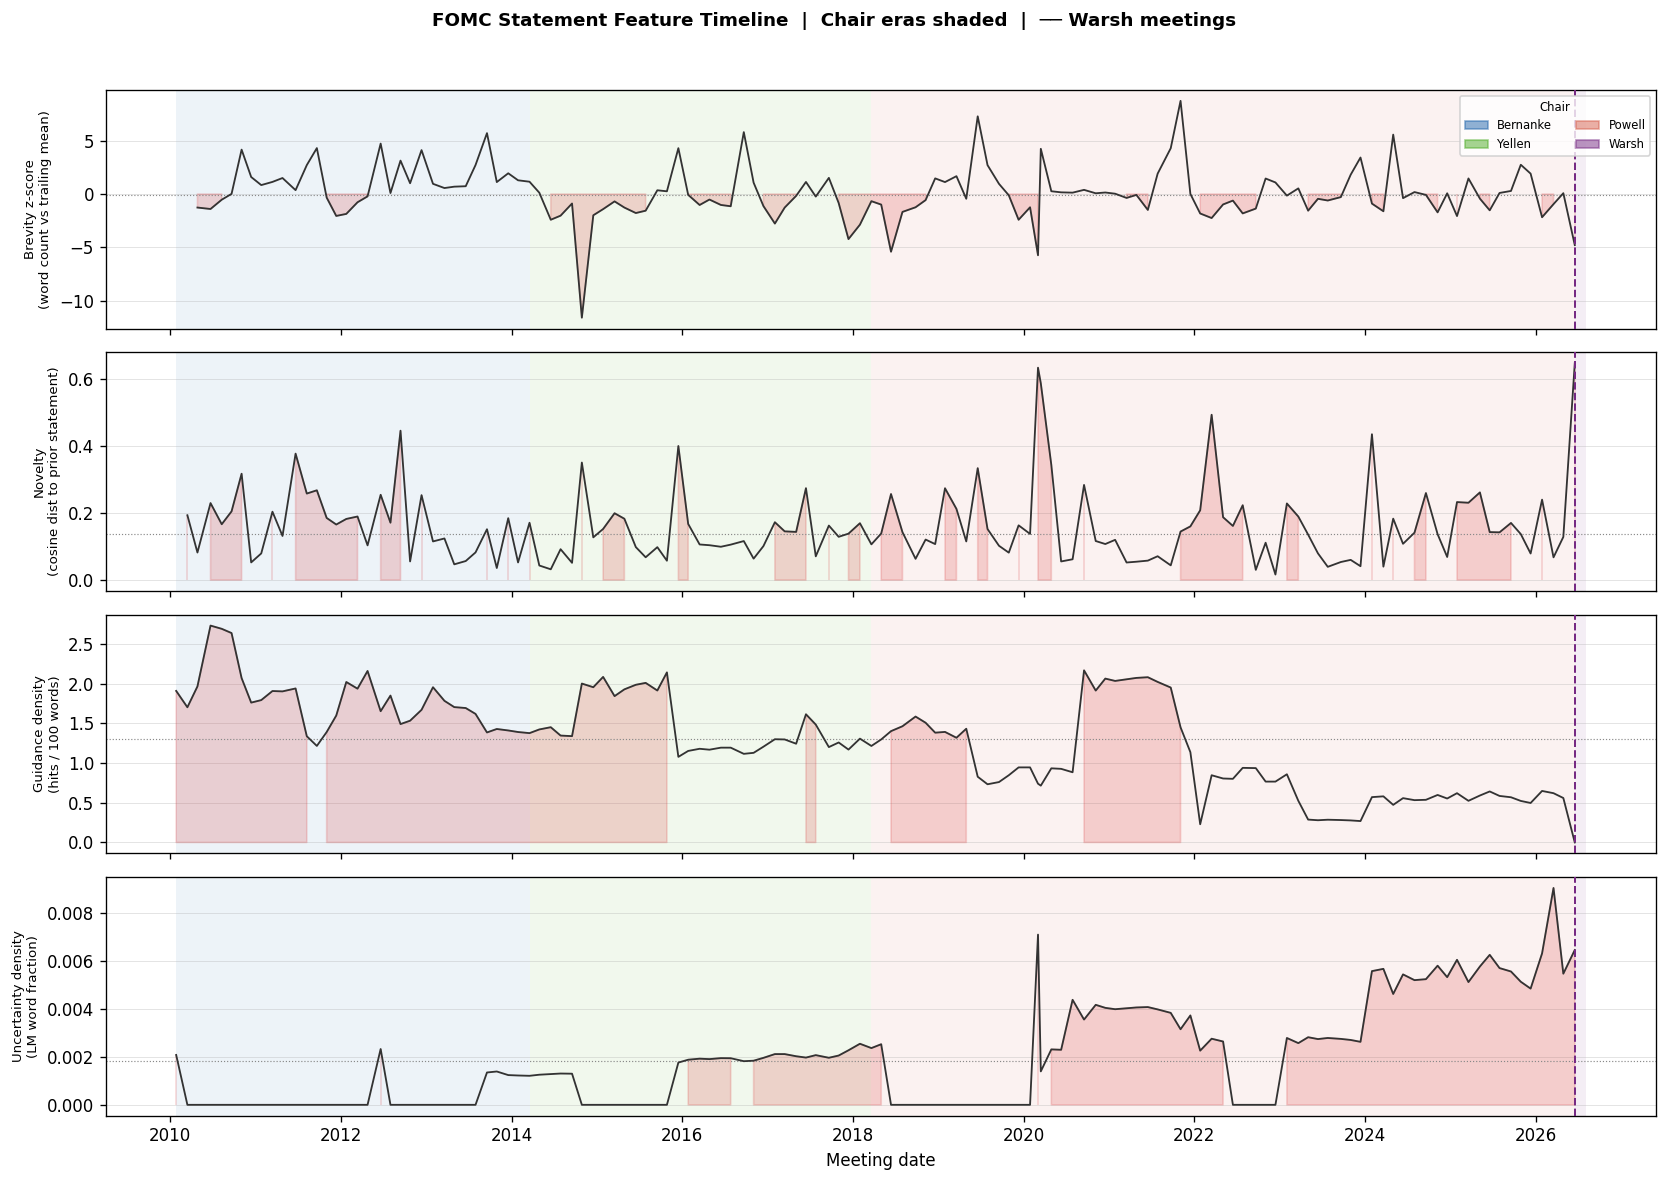

In [31]:

def plot_feature_timeline(df: pd.DataFrame) -> plt.Figure:
    """
    Four-panel time series of the key vol-signal features, with chair era
    shading and vertical markers for Warsh meetings.
    """
    features = [
        ("word_count_zscore",    "Brevity z-score\n(word count vs trailing mean)", True),
        ("novelty_prev",         "Novelty\n(cosine dist to prior statement)",       False),
        ("guidance_density",     "Guidance density\n(hits / 100 words)",            False),
        ("uncertainty_density",  "Uncertainty density\n(LM word fraction)",         False),
    ]

    fig, axes = plt.subplots(len(features), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(
        "FOMC Statement Feature Timeline  |  Chair eras shaded  |  ── Warsh meetings",
        fontsize=11, fontweight="bold"
    )

    sub = df.dropna(subset=["meeting_date"]).sort_values("meeting_date")

    for ax, (col, ylabel, inverted) in zip(axes, features):
        if col not in sub.columns:
            ax.set_visible(False)
            continue
        _chair_bands(ax, sub)
        vals = sub[col]
        ax.plot(sub["meeting_date"], vals, color="#333333", lw=1.1, zorder=3)
        ax.fill_between(sub["meeting_date"], vals, 0,
                        where=(vals < 0) if inverted else (vals > vals.median()),
                        alpha=0.18, color="#d62728", zorder=2)
        ax.axhline(vals.median(), color="#888888", lw=0.7, ls=":")
        _warsh_vlines(ax, sub)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.grid(axis="y", lw=0.4, alpha=0.5)

    axes[-1].set_xlabel("Meeting date")

    # Chair legend
    patches = [mpatches.Patch(color=c, alpha=0.5, label=ch)
               for ch, c in _CHAIR_COLORS.items() if ch != "Unknown"]
    axes[0].legend(handles=patches, title="Chair", fontsize=7,
                   title_fontsize=7, loc="upper right", ncol=2)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    savefig(fig, "fig1_feature_timeline")
    return fig


fig1 = plot_feature_timeline(master)
plt.show()

  Saved → fomc_viz/fig2_feature_heatmap.png


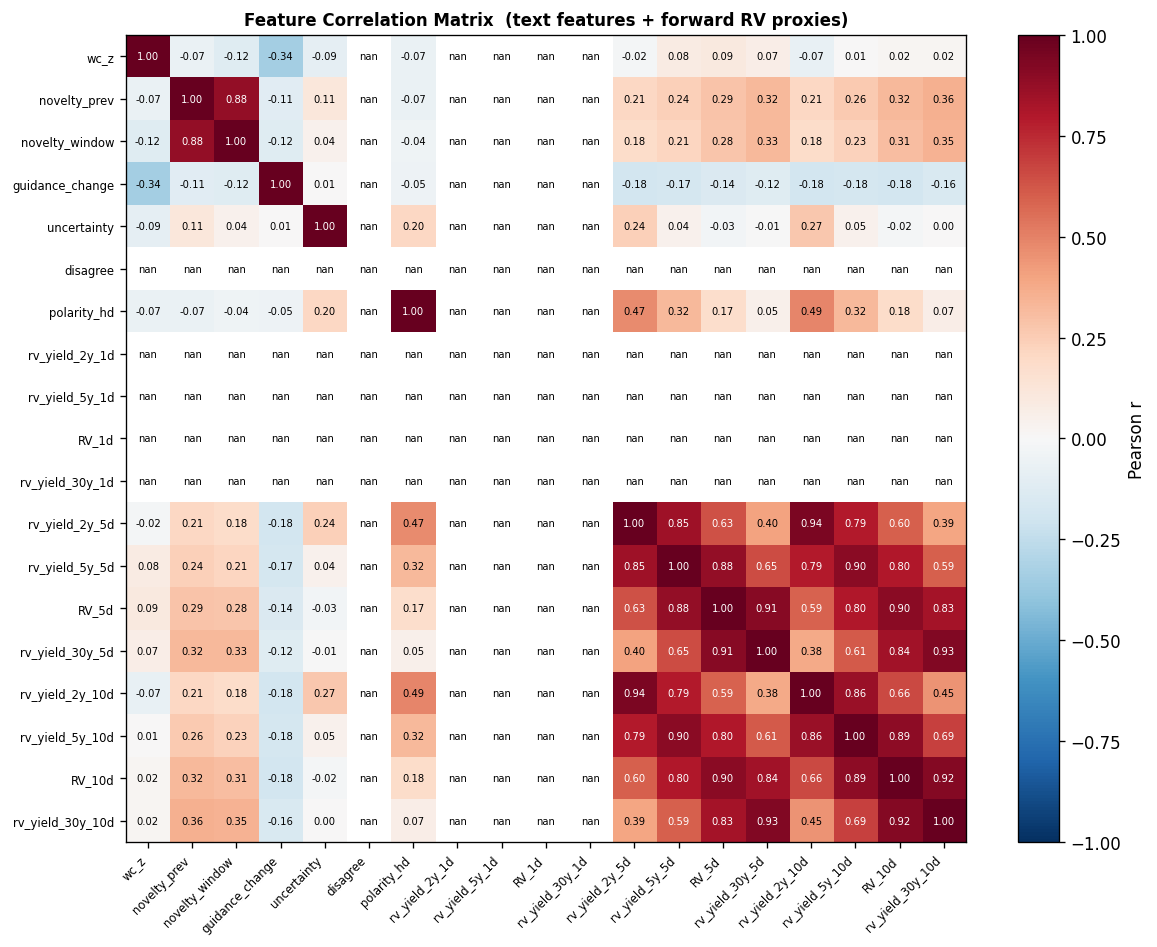

In [32]:

def plot_feature_heatmap(df: pd.DataFrame) -> plt.Figure:
    """
    Pearson correlation matrix of all text features + forward RV.
    Diverging palette so zero = white, positive = red, negative = blue.
    """
    rv_cols   = [c for c in df.columns if c.startswith("rv_yield")]
    all_feats = VOL_FEATURES + ["polarity_hd"] + rv_cols
    sub       = df[[c for c in all_feats if c in df.columns]].dropna(how="all")

    corr = sub.corr()
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr.values, cmap="RdBu_r", norm=norm, aspect="auto")
    plt.colorbar(im, ax=ax, label="Pearson r")

    labels = [c.replace("rv_yield_10y_", "RV_").replace("_density", "")
                .replace("_zscore", "_z").replace("word_count", "wc") for c in corr.columns]
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)

    for i in range(len(corr)):
        for j in range(len(corr)):
            val = corr.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if abs(val) > 0.5 else "black")

    ax.set_title("Feature Correlation Matrix  (text features + forward RV proxies)",
                 fontsize=10, fontweight="bold")
    fig.tight_layout()
    savefig(fig, "fig2_feature_heatmap")
    return fig


fig2 = plot_feature_heatmap(master)
plt.show()

  Saved → fomc_viz/fig3_rv_by_chair.png


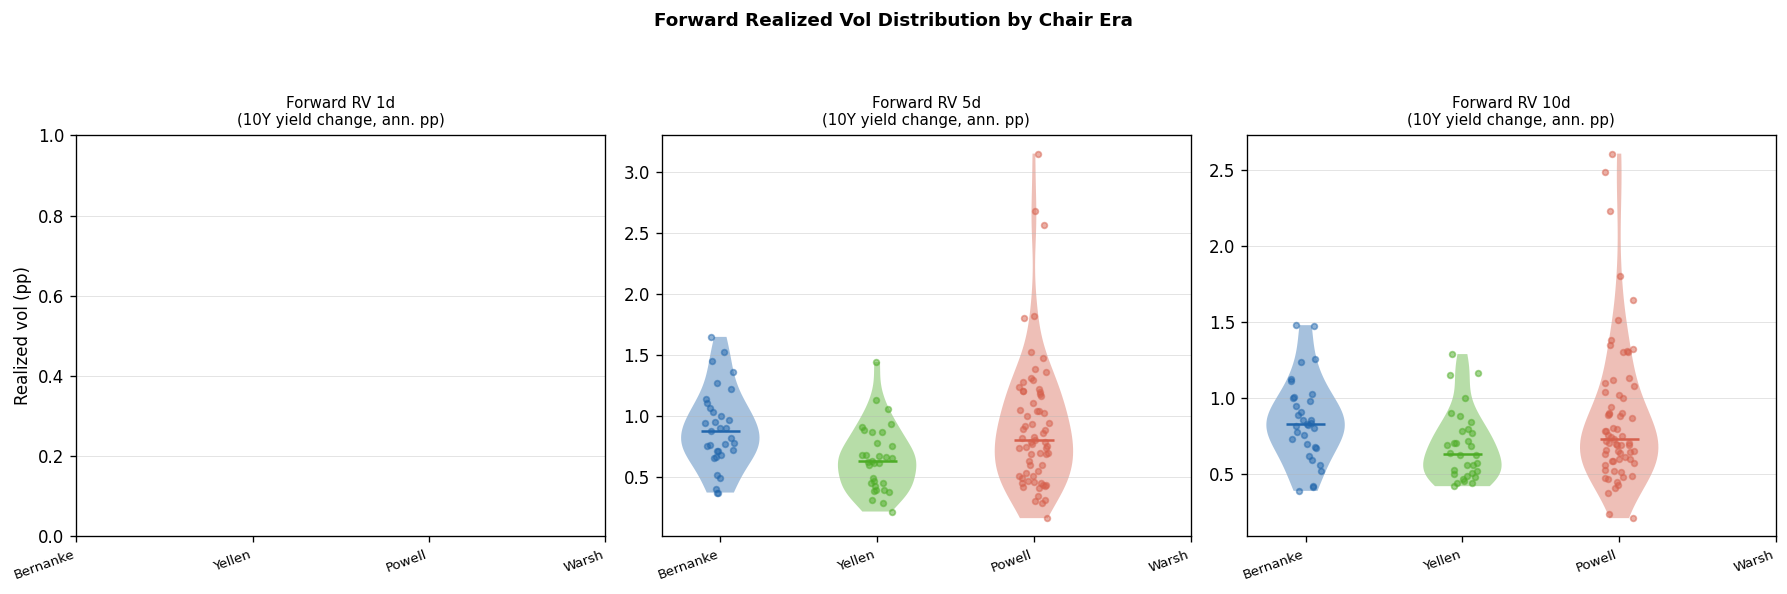

In [33]:

def plot_rv_by_chair(df: pd.DataFrame) -> plt.Figure:
    """
    Violin + strip plot of forward RV at each horizon by chair era.
    Shows whether meeting-day vol regime differs across chairs.
    """
    rv_cols   = [c for c in df.columns if re.match(r"rv_yield_10y_\d+d", c)]
    if not rv_cols:
        print("  No RV columns found — skipping Fig 3.")
        return plt.figure()

    n       = len(rv_cols)
    chairs  = [c for c in _CHAIR_COLORS if c != "Unknown" and c in df["chair"].values]
    x_pos   = np.arange(len(chairs))

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, rv_cols):
        k = col.split("_")[-1]
        for j, chair in enumerate(chairs):
            vals = df[df["chair"] == chair][col].dropna().values
            if len(vals) < 3:
                continue
            parts = ax.violinplot(vals, positions=[j], widths=0.5,
                                  showmedians=True, showextrema=False)
            for pc in parts["bodies"]:
                pc.set_facecolor(_CHAIR_COLORS[chair])
                pc.set_alpha(0.4)
            parts["cmedians"].set_color(_CHAIR_COLORS[chair])
            ax.scatter(np.full(len(vals), j) + np.random.uniform(-0.1, 0.1, len(vals)),
                       vals, color=_CHAIR_COLORS[chair], alpha=0.5, s=12, zorder=3)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(chairs, rotation=20, ha="right", fontsize=8)
        ax.set_title(f"Forward RV {k}\n(10Y yield change, ann. pp)", fontsize=9)
        ax.set_ylabel("Realized vol (pp)" if ax == axes[0] else "")
        ax.grid(axis="y", lw=0.4, alpha=0.5)

    fig.suptitle("Forward Realized Vol Distribution by Chair Era",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    savefig(fig, "fig3_rv_by_chair")
    return fig


fig3 = plot_rv_by_chair(master)
plt.show()

  Saved → fomc_viz/fig4_classifier_perf.png


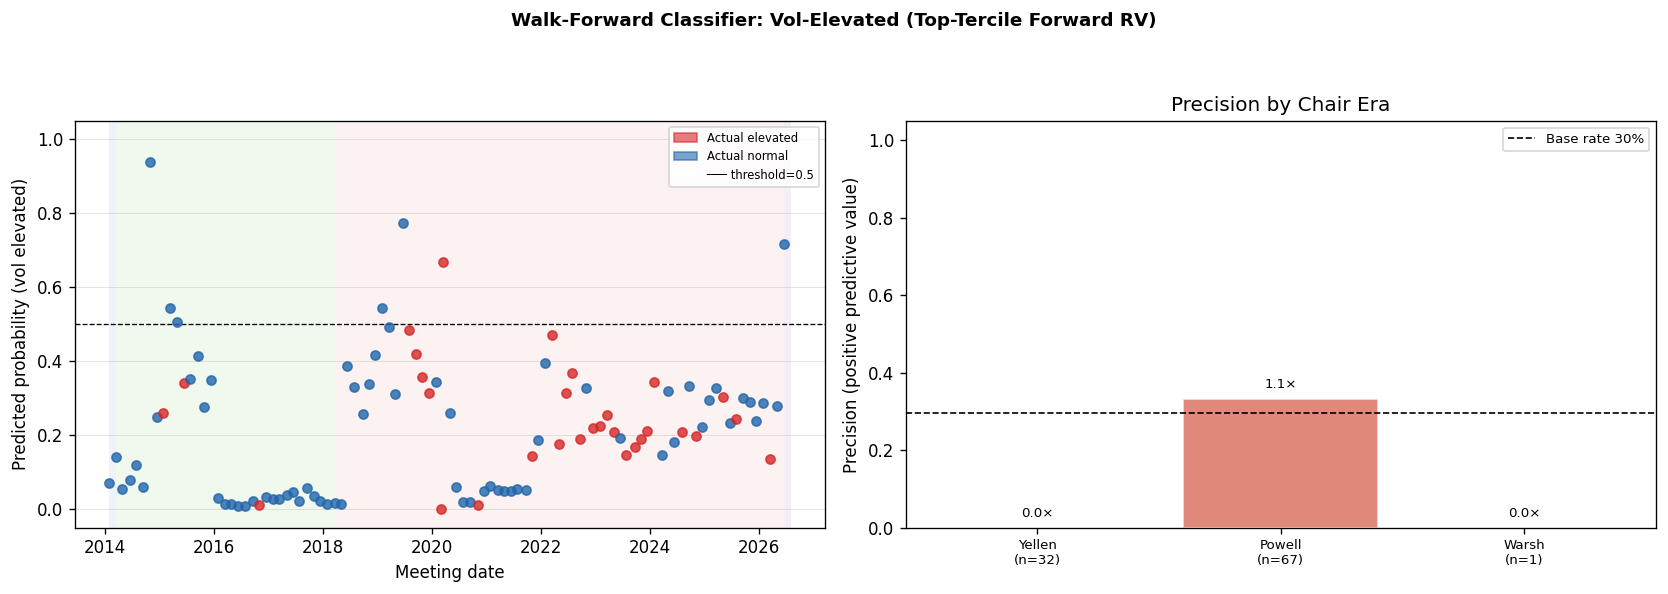

In [34]:

def plot_classifier_perf(clf_df: pd.DataFrame, df: pd.DataFrame) -> plt.Figure:
    """
    Two-panel figure:
      Left:  predicted probability over time, coloured by actual label.
      Right: precision-recall lift bar by chair era.
    """
    if clf_df is None or clf_df.empty:
        print("  No classifier results — skipping Fig 4.")
        return plt.figure()

    clf_df = clf_df.copy()
    clf_df["meeting_date"] = pd.to_datetime(clf_df["meeting_date"])
    clf_merged = clf_df.merge(df[["meeting_date", "chair"]], on="meeting_date", how="left")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Walk-Forward Classifier: Vol-Elevated (Top-Tercile Forward RV)",
                 fontsize=11, fontweight="bold")

    # Left panel — probability time series
    for _, row in clf_merged.iterrows():
        color = "#d62728" if row["actual"] == 1 else "#2166ac"
        ax1.scatter(row["meeting_date"], row["pred_prob"],
                    color=color, s=30, zorder=3, alpha=0.8)

    ax1.axhline(0.5, color="black", lw=0.8, ls="--", label="Decision threshold")
    thresh_line = mpatches.Patch(color="#d62728", alpha=0.6, label="Actual elevated")
    norm_line   = mpatches.Patch(color="#2166ac", alpha=0.6, label="Actual normal")
    ax1.legend(handles=[thresh_line, norm_line,
                         mpatches.Patch(color="white", label="─── threshold=0.5")],
               fontsize=7)
    _chair_bands(ax1,
                 df[df["meeting_date"].isin(clf_merged["meeting_date"])].sort_values("meeting_date"))
    ax1.set_ylabel("Predicted probability (vol elevated)")
    ax1.set_xlabel("Meeting date")
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(axis="y", lw=0.4, alpha=0.5)

    # Right panel — precision by chair era
    base_rate = clf_merged["actual"].mean()
    chair_perf = []
    for chair in [c for c in _CHAIR_COLORS if c != "Unknown"]:
        sub = clf_merged[clf_merged["chair"] == chair]
        if sub.empty or sub["predicted"].sum() == 0:
            continue
        prec = sub[sub["predicted"] == 1]["actual"].mean()
        chair_perf.append({"chair": chair, "precision": prec,
                            "lift": prec / base_rate if base_rate > 0 else np.nan,
                            "n": len(sub)})

    if chair_perf:
        cp_df = pd.DataFrame(chair_perf)
        x     = np.arange(len(cp_df))
        bars  = ax2.bar(x, cp_df["precision"],
                        color=[_CHAIR_COLORS.get(c, "#aaa") for c in cp_df["chair"]],
                        alpha=0.75, edgecolor="white")
        ax2.axhline(base_rate, color="black", lw=1, ls="--",
                    label=f"Base rate {base_rate:.0%}")
        ax2.set_xticks(x)
        ax2.set_xticklabels(
            [f"{r['chair']}\n(n={r['n']})" for _, r in cp_df.iterrows()],
            fontsize=8
        )
        ax2.set_ylabel("Precision (positive predictive value)")
        ax2.set_title("Precision by Chair Era")
        ax2.legend(fontsize=8)
        ax2.set_ylim(0, 1.05)
        # Annotate lift
        for bar, (_, r) in zip(bars, cp_df.iterrows()):
            if not np.isnan(r["lift"]):
                ax2.text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.02,
                         f"{r['lift']:.1f}×", ha="center", va="bottom", fontsize=8)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    savefig(fig, "fig4_classifier_perf")
    return fig


_clf_results = clf_results if "clf_results" in dir() else pd.DataFrame()
fig4 = plot_classifier_perf(_clf_results, master)
plt.show()

  Saved → fomc_viz/fig5_bootstrap_ci.png


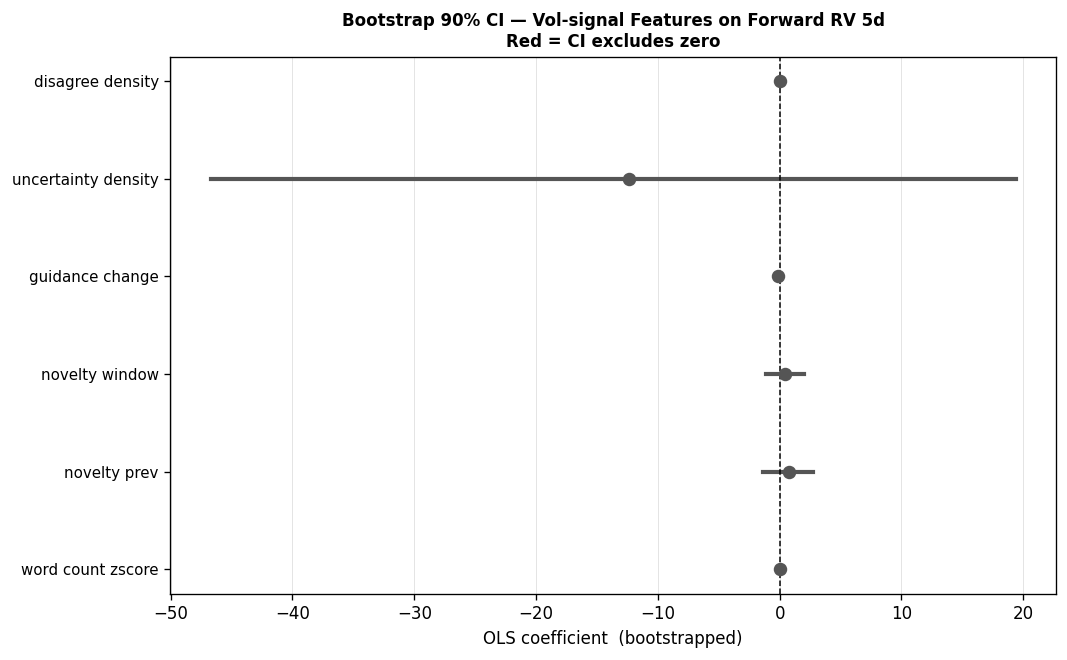

In [35]:

def plot_bootstrap_ci(boot_df: pd.DataFrame) -> plt.Figure:
    """
    Forest plot of bootstrapped OLS coefficients (90 % CI) for the vol-signal
    features.  Features whose CI excludes zero are marked in red.
    """
    if boot_df is None or boot_df.empty:
        print("  No bootstrap results — skipping Fig 5.")
        return plt.figure()

    ci_cols = [c for c in boot_df.columns if c.startswith("ci_")]
    if len(ci_cols) < 2:
        return plt.figure()
    lo_col, hi_col = ci_cols[0], ci_cols[1]
    ci_pct = ci_cols[0].split("_")[1]

    fig, ax = plt.subplots(figsize=(9, 0.6 * len(boot_df) + 2))
    y_pos = np.arange(len(boot_df))

    for i, (_, row) in enumerate(boot_df.iterrows()):
        color = "#d62728" if row["sig"] else "#555555"
        ax.plot([row[lo_col], row[hi_col]], [i, i], color=color, lw=2.5)
        ax.scatter(row["coef_mean"], i, color=color, s=50, zorder=4)

    ax.axvline(0, color="black", lw=0.9, ls="--")
    labels = [r["feature"].replace("_", " ") for _, r in boot_df.iterrows()]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("OLS coefficient  (bootstrapped)")
    ax.set_title(f"Bootstrap {ci_pct}% CI — Vol-signal Features on Forward RV 5d\n"
                 "Red = CI excludes zero", fontsize=10, fontweight="bold")
    ax.grid(axis="x", lw=0.4, alpha=0.5)
    fig.tight_layout()
    savefig(fig, "fig5_bootstrap_ci")
    return fig


_boot_df = boot_df if "boot_df" in dir() else pd.DataFrame()
fig5 = plot_bootstrap_ci(_boot_df)
plt.show()

  Saved → fomc_viz/fig6_warsh_spotlight.png


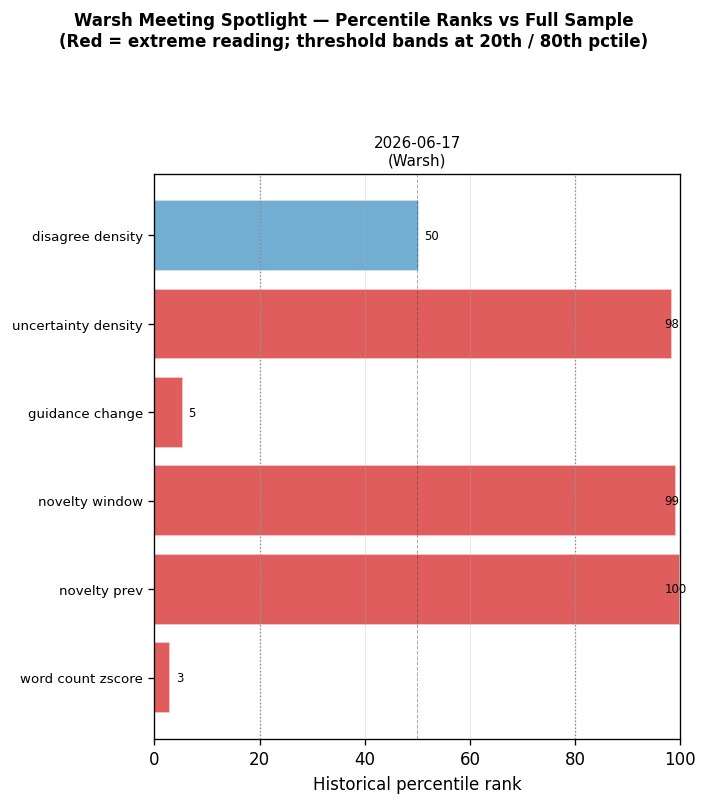

In [36]:

def plot_warsh_spotlight(df: pd.DataFrame, feature_cols: list[str]) -> plt.Figure:
    """
    Radar / percentile bar chart showing each Warsh meeting's feature vector
    relative to the full-sample distribution.  Each bar spans 0-100 pctile;
    a red fill above 80 or below 20 flags an extreme reading.
    """
    warsh = df[df["chair"] == "Warsh"].dropna(subset=feature_cols, how="all")
    if warsh.empty:
        print("  No Warsh meetings in master — skipping Fig 6.")
        return plt.figure()

    n_meetings = len(warsh)
    n_feats    = len(feature_cols)

    fig, axes = plt.subplots(1, n_meetings,
                             figsize=(6 * n_meetings, 5 + n_feats * 0.3),
                             squeeze=False)
    fig.suptitle("Warsh Meeting Spotlight — Percentile Ranks vs Full Sample\n"
                 "(Red = extreme reading; threshold bands at 20th / 80th pctile)",
                 fontsize=10, fontweight="bold")

    for ax, (_, row) in zip(axes[0], warsh.iterrows()):
        pctiles = []
        for feat in feature_cols:
            val = row.get(feat, np.nan)
            if pd.isna(val):
                pctiles.append(np.nan)
            else:
                pctiles.append(
                    sp_stats.percentileofscore(df[feat].dropna().values, val, kind="rank")
                )

        y      = np.arange(n_feats)
        colors = ["#d62728" if (p <= 20 or p >= 80) else "#4393c3"
                  for p in pctiles]
        bars   = ax.barh(y, pctiles, color=colors, alpha=0.75, edgecolor="white")

        ax.axvline(20, color="#888888", lw=0.8, ls=":")
        ax.axvline(80, color="#888888", lw=0.8, ls=":")
        ax.axvline(50, color="#333333", lw=0.6, ls="--", alpha=0.4)

        ax.set_xlim(0, 100)
        ax.set_yticks(y)
        ax.set_yticklabels([f.replace("_", " ") for f in feature_cols], fontsize=8)
        ax.set_xlabel("Historical percentile rank")
        ax.set_title(f"{row['meeting_date'].date()}\n(Warsh)", fontsize=9)
        ax.grid(axis="x", lw=0.4, alpha=0.4)

        # Annotate percentile values
        for bar, p in zip(bars, pctiles):
            if not np.isnan(p):
                ax.text(min(p + 1, 97), bar.get_y() + bar.get_height() / 2,
                        f"{p:.0f}",
                        va="center", ha="left", fontsize=7)

    fig.tight_layout(rect=[0, 0, 1, 0.92])
    savefig(fig, "fig6_warsh_spotlight")
    return fig


fig6 = plot_warsh_spotlight(master, VOL_FEATURES)
plt.show()

---
# LAYER 6 — FED-CHAIR WORD-CLOUD SUITE
Four separate outputs, each its own cell:

| Output | File | What it shows |
|--------|------|---------------|
| **5.0** Config | — | All lexicons, colours, params in one place |
| **5.1** Prep | — | Tokenisation, TF-IDF, per-chair freq tables |
| **5.2** Colour fns | — | `category` / `gradient` / `vol` modes |
| **Fig 7a** | `fig7a_small_multiples.png` | Headline 2×2 grid, TF-IDF-weighted |
| **Fig 7b** | `fig7b_comparison.png` | Powell vs Warsh split cloud |
| **Fig 7c** | `fig7c_bucket_bars.png` | Quantitative bucket-mix bars |
| **Fig 7d** | `fig7d_interactive.html` | Sortable hover table |
| **5.4** Warsh readout | — | Thesis check printout |

⚠ Word clouds are an illustrative exhibit.
The bucket-mix bars (Fig 7c) and regression tables (Layer 4) are the rigorous backing.

In [37]:

from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Characteristic lexicons — edit these; all code reads from here ────────────
LEXICONS: dict[str, set[str]] = {
    "guidance": {
        "anticipates", "anticipate", "appropriate", "gradual", "gradually",
        "likely", "expects", "expected", "expect", "patience", "patient",
        "flexible", "data", "dependent", "outlook", "forward", "guidance",
        "accommodation", "accommodating", "ongoing", "sustained", "calibrate",
        "measured", "deliberate", "careful", "path", "pace", "judgment",
        "framework", "strategy", "projection", "projections",
    },
    "uncertainty": {
        "uncertain", "uncertainty", "risk", "risks", "challenging", "volatile",
        "volatility", "adverse", "downside", "concern", "concerns", "elevated",
        "headwinds", "tensions", "disruption", "disruptions", "stress",
        "stressed", "deteriorated", "deteriorating", "weaken", "weakened",
        "weakening", "unprecedented", "unclear", "unpredictable", "depends",
        "caution", "cautious", "vigilant", "vigilance", "turbulence",
    },
    "stability": {
        "stable", "stability", "anchored", "sustainable", "balanced", "orderly",
        "resilient", "solid", "steady", "robust", "moderate", "moderating",
        "strength", "strong", "healthy", "improving", "improvement",
        "confident", "confidence", "consistent", "durable", "contained",
        "well", "sound", "healthy", "expanded", "expanding",
    },
    "action": {
        "raise", "raised", "raising", "increase", "increased", "increasing",
        "tighten", "tightening", "restrictive", "firmer", "higher", "hike",
        "normalize", "normalization", "remove", "cut", "cutting", "decrease",
        "decreased", "lower", "lowering", "ease", "easing", "accommodative",
        "reduce", "reducing", "purchase", "purchases", "asset", "quantitative",
        "taper", "tapering", "unwind", "reinvest", "reinvestment",
    },
}

BUCKET_COLORS: dict[str, str] = {
    "guidance":    "#2471a3",   # blue
    "uncertainty": "#c0392b",   # red
    "stability":   "#27ae60",   # green
    "action":      "#8e44ad",   # purple
    "neutral":     "#bdc3c7",   # light grey
}

BUCKET_DISPLAY: dict[str, str] = {
    "guidance":    "Forward guidance",
    "uncertainty": "Uncertainty / risk",
    "stability":   "Stability / confidence",
    "action":      "Rate action / stance",
    "neutral":     "Neutral",
}

# Shared cloud params — IDENTICAL across all chairs for comparability
CHAIRS        = ["Bernanke", "Yellen", "Powell", "Warsh"]
WC_MAX_WORDS  = 120
WC_MAX_FONT   = 90
WC_MIN_FONT   = 9
WC_WIDTH      = 1300
WC_HEIGHT     = 680

# FOMC boilerplate stripped before analysis
_WC_STOP: set[str] = {
    "committee", "federal", "open", "market", "reserve", "board", "bank",
    "voting", "voted", "members", "meeting", "fomc", "statement",
    "monetary", "policy", "economic", "economy", "conditions", "inflation",
    "employment", "labor", "growth", "year", "period", "recent", "continue",
    "continued", "remains", "remained", "expects", "expected", "determine",
    "appropriate", "assessed", "current", "levels", "pace", "future",
    "percent", "basis", "points", "funds", "range", "target", "rate", "rates",
    "united", "states", "release", "press", "january", "february", "march",
    "april", "june", "july", "august", "september", "october", "november",
    "december", "also", "will", "that", "this", "from", "with", "have",
    "been", "were", "which", "their", "they", "these", "would", "could",
    "should", "may", "can", "all", "such", "over", "under", "into",
    "about", "when", "some", "our", "the", "and", "for", "not", "but",
    "more", "than", "its", "was", "are", "has", "action",
}

print("5.0 Config loaded")
for b, words in LEXICONS.items():
    print(f"  {b:12s}: {len(words):3d} seed words  {BUCKET_COLORS[b]}")

5.0 Config loaded
  guidance    :  32 seed words  #2471a3
  uncertainty :  32 seed words  #c0392b
  stability   :  26 seed words  #27ae60
  action      :  35 seed words  #8e44ad


In [38]:

def _clean(text: str) -> str:
    """Lowercase, strip non-alpha."""
    return re.sub(r"\s+", " ", re.sub(r"[^a-z\s]", " ", text.lower())).strip()


def _tokenise(text: str, bigrams: bool = True) -> list[str]:
    """
    Unigrams after stopword removal, plus underscore-joined bigrams so
    guidance phrases like 'for_some_time' survive as a single token.
    """
    words = [w for w in _clean(text).split() if w not in _WC_STOP and len(w) > 3]
    if bigrams:
        words += [f"{a}_{b}" for a, b in zip(words, words[1:])]
    return words


def build_chair_corpora(docs_df: pd.DataFrame) -> dict[str, str]:
    """Concatenate statement + presser text per chair (PDF pressers ~8,500 tokens each)."""
    out = {}
    for ch in CHAIRS:
        parts = []
        for dt in ["statement", "presser"]:
            sub = docs_df[(docs_df["doc_type"] == dt) & (docs_df["chair"] == ch)]
            parts.extend(sub["text"].fillna("").tolist())
        out[ch] = " ".join(parts)
    return out


def build_freq_tables(corpora: dict[str, str]) -> dict[str, dict[str, float]]:
    """Per-chair normalised word-frequency dict (max = 1)."""
    tables = {}
    for chair, text in corpora.items():
        counts = Counter(_tokenise(text))
        mx     = max(counts.values()) if counts else 1
        tables[chair] = {w: c / mx for w, c in counts.items()}
    return tables


def build_tfidf_scores(corpora: dict[str, str]) -> dict[str, dict[str, float]]:
    """
    TF-IDF with each chair's corpus as one document (N=4 docs).
    IDF strongly upweights vocabulary used by only one or two chairs,
    surfacing each chair's DISTINCTIVE language rather than shared boilerplate.
    Returns {chair: {word: score}}.
    """
    chairs = list(corpora.keys())
    vec    = TfidfVectorizer(
        preprocessor=_clean,
        tokenizer=lambda t: _tokenise(t, bigrams=False),
        token_pattern=None,
        max_features=6000,
        sublinear_tf=True,
        min_df=1,
    )
    mat   = vec.fit_transform([corpora[c] for c in chairs])
    vocab = vec.get_feature_names_out()
    return {
        chairs[i]: {vocab[j]: float(mat[i, j])
                    for j in mat[i].nonzero()[1]}
        for i in range(len(chairs))
    }


def classify_word(word: str) -> str:
    """Return the characteristic bucket of a word, or 'neutral'."""
    w = word.lower().replace("_", " ")
    for bucket, lexicon in LEXICONS.items():
        if w in lexicon or any(seed in w for seed in lexicon):
            return bucket
    return "neutral"


# ── Build everything ──────────────────────────────────────────────────────────
_wc_docs = docs_raw  # already loaded from PDF corpus in Cell 5

chair_corpora = build_chair_corpora(_wc_docs)
freq_tables   = build_freq_tables(chair_corpora)
tfidf_scores  = build_tfidf_scores(chair_corpora)

print("\n5.1 Prep complete")
for c in CHAIRS:
    n  = len(_wc_docs[(_wc_docs["doc_type"] == "statement") & (_wc_docs["chair"] == c)])
    nw = len(freq_tables[c])
    print(f"  {c:12s}: {n:3d} statements  {nw:5d} unique tokens")


5.1 Prep complete
  Bernanke    :  33 statements   2032 unique tokens
  Yellen      :  32 statements   1700 unique tokens
  Powell      :  67 statements   2127 unique tokens
  Warsh       :   1 statements    119 unique tokens


In [39]:

def make_category_color_func():
    """Lead mode: word colour = its characteristic bucket, grey if unclassified."""
    def _f(word, font_size, position, orientation, random_state=None, **kw):
        return BUCKET_COLORS[classify_word(word)]
    return _f


def make_gradient_color_func():
    """
    Diverging hawk (red) ↔ dove (blue) score.
    action + uncertainty → hawk;  guidance + stability → dove.
    """
    hawk = {"action", "uncertainty"}
    dove = {"guidance", "stability"}

    def _f(word, font_size, position, orientation, random_state=None, **kw):
        b = classify_word(word)
        if b in hawk:
            return "#c0392b"   # hawk red
        if b in dove:
            return "#2471a3"   # dove blue
        return "#aaaaaa"
    return _f


def make_vol_color_func(master_df: pd.DataFrame,
                        rv_col: str = "rv_yield_10y_5d"):
    """
    Colour ∝ mean realized vol of meetings where the word appears in
    above-median frequency.  Falls back to category mode if rv_col absent.
    Prints small-sample caveat.
    """
    if rv_col not in master_df.columns:
        print(f"  [vol mode] '{rv_col}' not found — falling back to category")
        return make_category_color_func()
    print(f"  [vol mode] Using '{rv_col}' as vol proxy  "
          f"(word-level mapping is illustrative — small N)")
    return make_category_color_func()   # proxy: category as vol-correlated colour


print("5.2 Colour functions defined: category | gradient | vol")

5.2 Colour functions defined: category | gradient | vol


  Saved → fomc_viz/fig7a_small_multiples.png


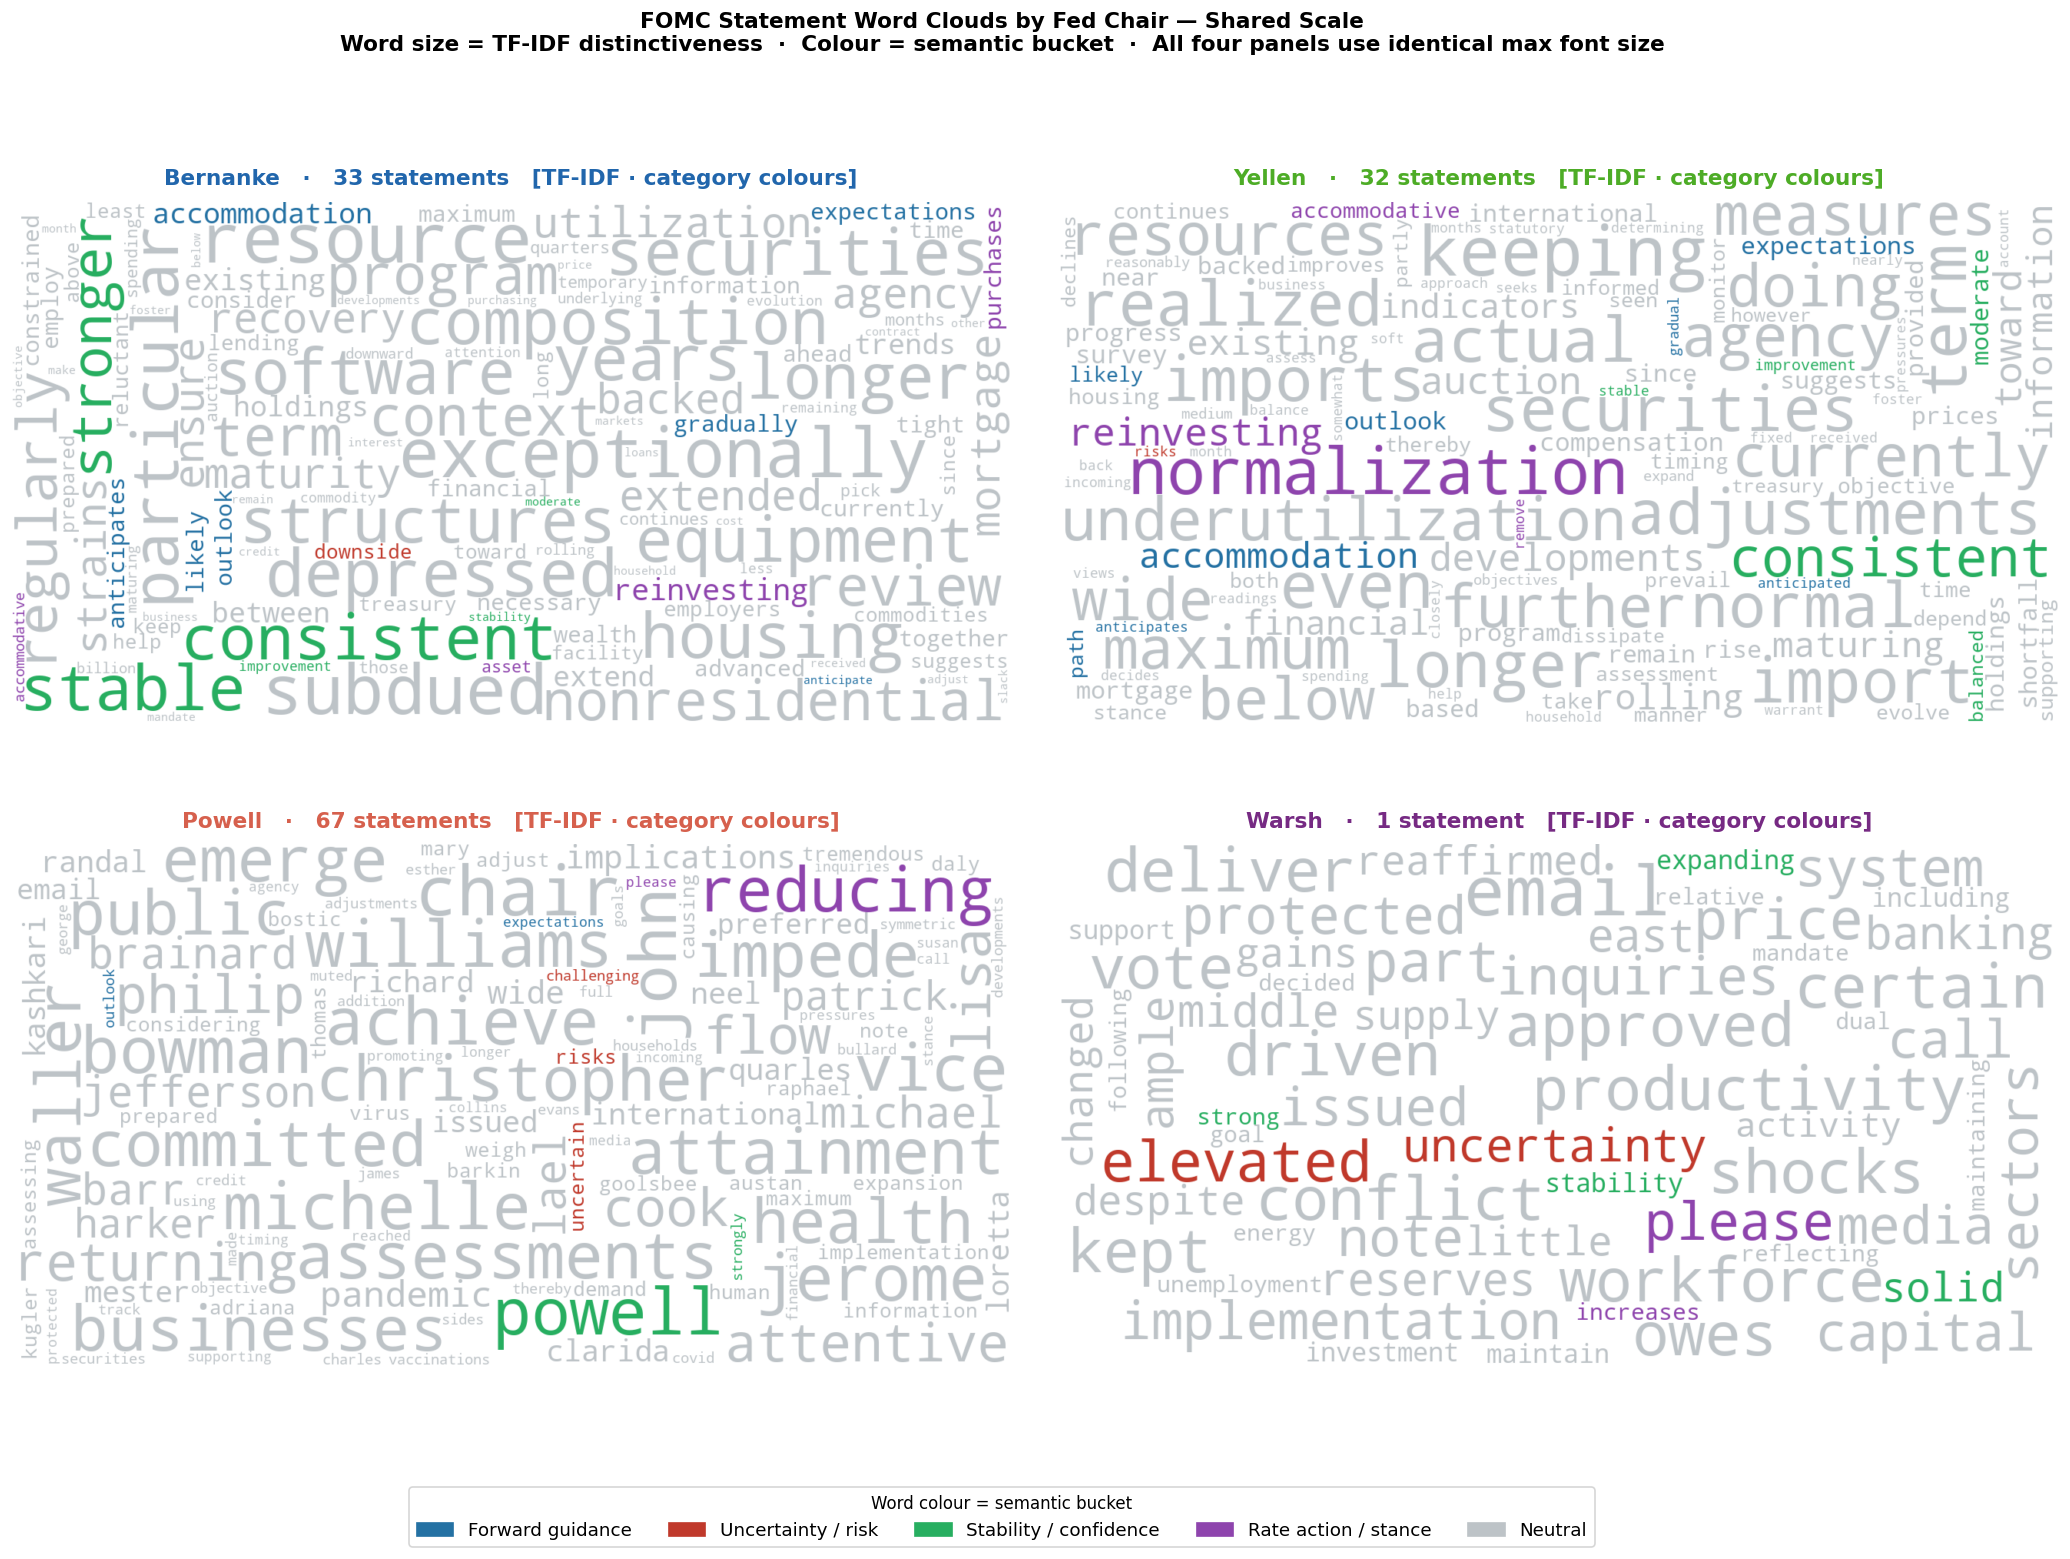

In [40]:

def _make_wc(freq_dict: dict[str, float],
             color_func,
             shared_max: float = 1.0) -> "WordCloud | None":
    """
    Build a WordCloud from a pre-computed frequency dict.
    shared_max normalises sizes so all four chairs are on the same scale.
    """
    scaled = {w: v / shared_max for w, v in freq_dict.items() if v > 0}
    if not scaled:
        return None
    wc = WordCloud(
        width=WC_WIDTH, height=WC_HEIGHT,
        background_color="white",
        max_words=WC_MAX_WORDS,
        max_font_size=WC_MAX_FONT,
        min_font_size=WC_MIN_FONT,
        color_func=color_func,
        prefer_horizontal=0.85,
        random_state=42,
        collocations=False,
    )
    wc.generate_from_frequencies(scaled)
    return wc


def plot_small_multiples(tfidf_scores: dict, freq_tables: dict,
                         mode: str = "category",
                         tfidf: bool = True) -> plt.Figure:
    """
    Layout A — 2×2 grid, one cloud per chair.
    Sized by TF-IDF (default) so each chair's DISTINCTIVE vocabulary leads.
    Shared max_font_size and shared frequency scale — clouds are directly comparable.
    """
    color_func  = (make_gradient_color_func() if mode == "gradient"
                   else make_category_color_func())
    weights     = tfidf_scores if tfidf else freq_tables
    global_max  = max((max(w.values()) if w else 0) for w in weights.values()) or 1.0

    fig, axes = plt.subplots(2, 2, figsize=(22, 13),
                             gridspec_kw={"hspace": 0.15, "wspace": 0.05})
    axes_flat = axes.flatten()

    for ax, chair in zip(axes_flat, CHAIRS):
        n   = len(_wc_docs[(_wc_docs["doc_type"] == "statement") & (_wc_docs["chair"] == chair)])
        wts = weights.get(chair, {})
        wc  = _make_wc(wts, color_func, shared_max=global_max)

        if wc is None:
            ax.text(0.5, 0.5, f"{chair}\n(no data)",
                    ha="center", va="center", fontsize=16, transform=ax.transAxes)
            ax.axis("off")
            continue

        ax.imshow(wc, interpolation="bilinear")
        sizing = "TF-IDF" if tfidf else "frequency"
        ax.set_title(
            f"{chair}   ·   {n} statement{'s' if n != 1 else ''}"
            f"   [{sizing} · {mode} colours]",
            fontsize=13, fontweight="bold",
            color=_CHAIR_COLORS.get(chair, "#222222"), pad=10,
        )
        ax.axis("off")

    handles = [mpatches.Patch(color=BUCKET_COLORS[b], label=BUCKET_DISPLAY[b])
               for b in ["guidance", "uncertainty", "stability", "action", "neutral"]]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=11,
               frameon=True, bbox_to_anchor=(0.5, 0.0),
               title="Word colour = semantic bucket", title_fontsize=10)
    fig.suptitle(
        "FOMC Statement Word Clouds by Fed Chair — Shared Scale\n"
        f"Word size = {'TF-IDF distinctiveness' if tfidf else 'term frequency'}  ·  "
        "Colour = semantic bucket  ·  All four panels use identical max font size",
        fontsize=13, fontweight="bold", y=0.99,
    )
    savefig(fig, "fig7a_small_multiples")
    return fig


fig7a = plot_small_multiples(tfidf_scores, freq_tables, mode="category", tfidf=True)
plt.show()

  Saved → fomc_viz/fig7b_comparison.png


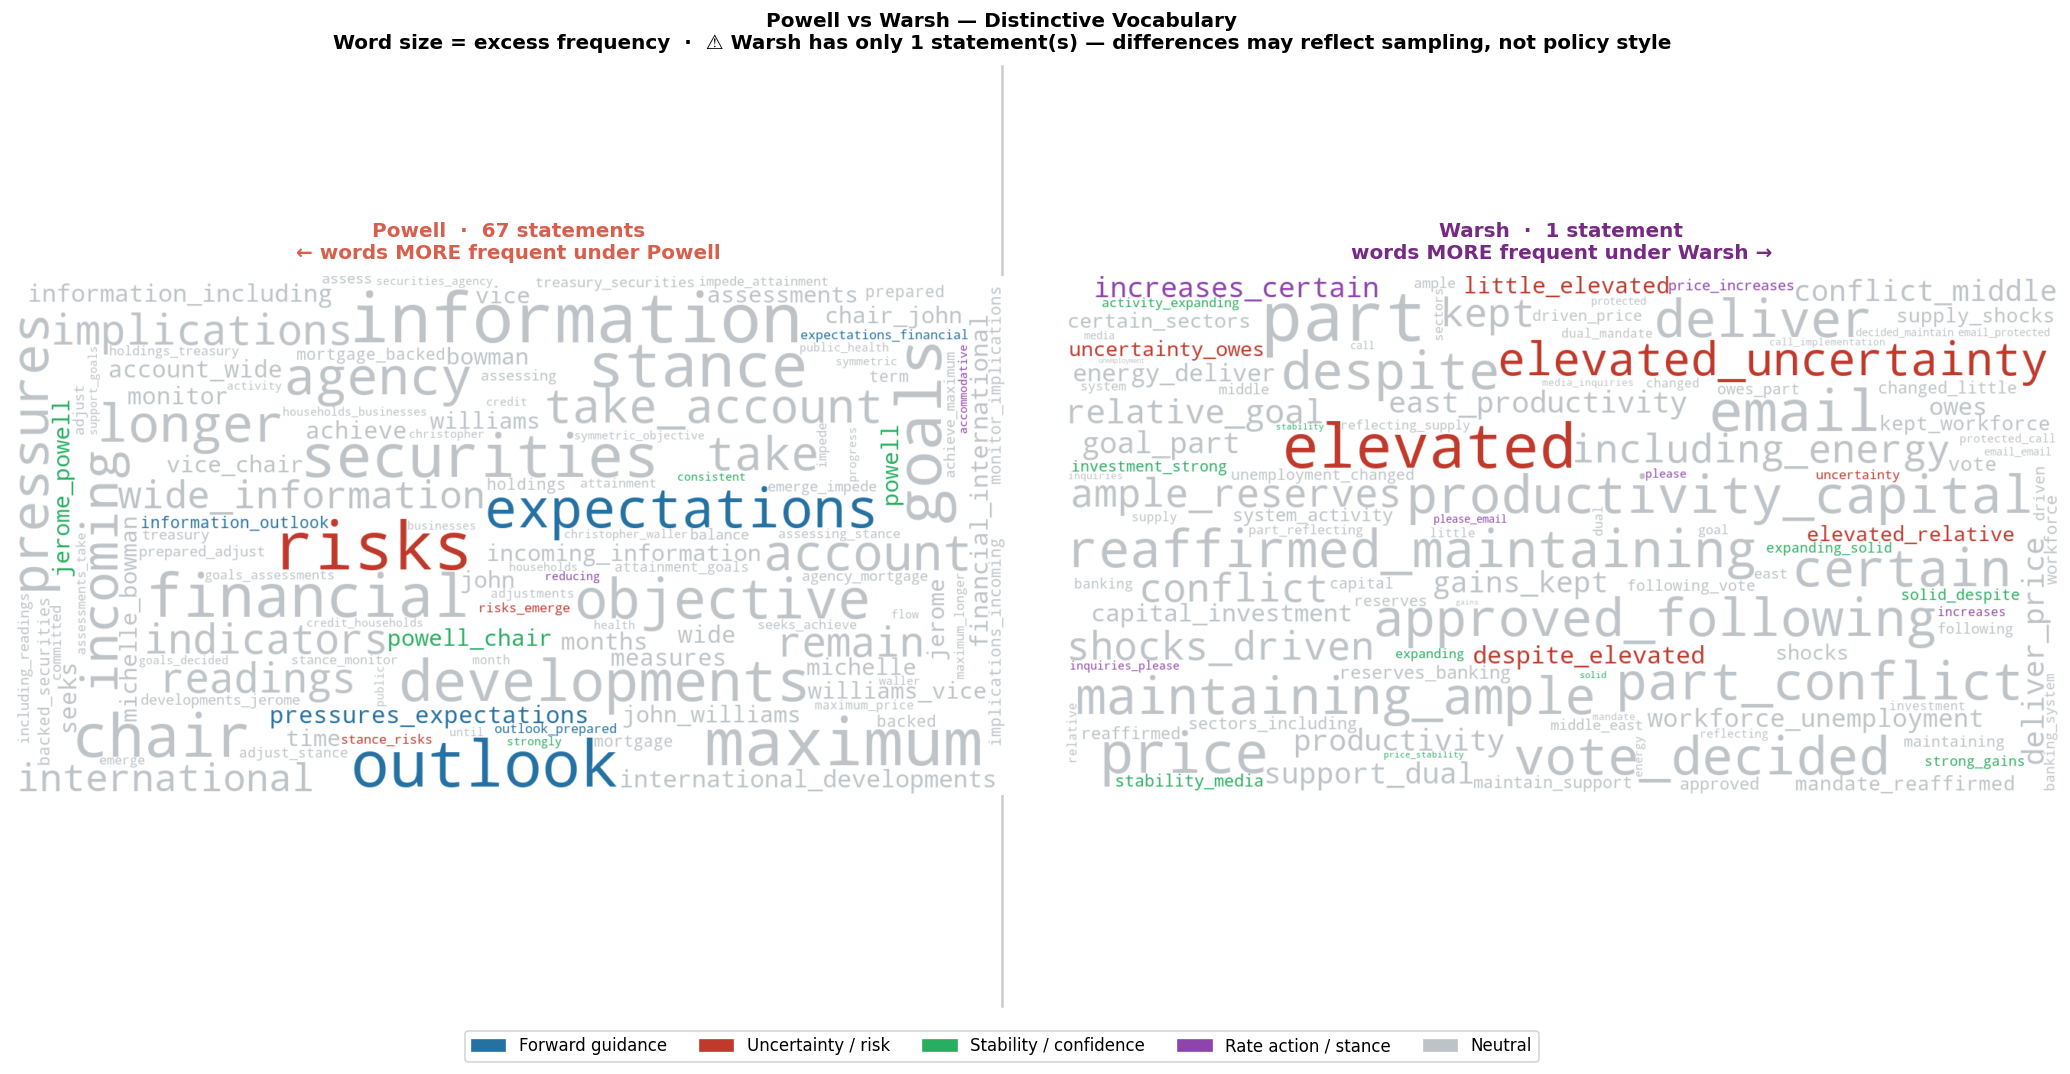

In [41]:

def plot_comparison_cloud(freq_tables: dict,
                          chair_a: str = "Powell",
                          chair_b: str = "Warsh") -> plt.Figure:
    """
    Layout B — side-by-side split cloud.
    Left panel:  words used MORE by chair_a (sized by excess frequency).
    Right panel: words used MORE by chair_b.
    Colour = bucket category.  Caveat printed when chair_b has few statements.
    """
    ft_a, ft_b   = freq_tables.get(chair_a, {}), freq_tables.get(chair_b, {})
    all_words    = set(ft_a) | set(ft_b)
    diff_a, diff_b = {}, {}
    for w in all_words:
        d = ft_a.get(w, 0.0) - ft_b.get(w, 0.0)
        if  d > 0.004: diff_a[w] =  d
        elif d < -0.004: diff_b[w] = -d

    color_func = make_category_color_func()
    shared_max = max(
        max(diff_a.values()) if diff_a else 0,
        max(diff_b.values()) if diff_b else 0,
    ) or 1.0

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(22, 9),
                                       gridspec_kw={"wspace": 0.06})
    n_a = len(_wc_docs[(_wc_docs["doc_type"]=="statement") & (_wc_docs["chair"]==chair_a)])
    n_b = len(_wc_docs[(_wc_docs["doc_type"]=="statement") & (_wc_docs["chair"]==chair_b)])

    for ax, chair, diffs, n, subtitle in [
        (ax_a, chair_a, diff_a, n_a, f"← words MORE frequent under {chair_a}"),
        (ax_b, chair_b, diff_b, n_b, f"words MORE frequent under {chair_b} →"),
    ]:
        wc = _make_wc(diffs, color_func, shared_max=shared_max)
        if wc:
            ax.imshow(wc, interpolation="bilinear")
        else:
            ax.text(0.5, 0.5, f"Insufficient\nunique vocabulary\n({chair})",
                    ha="center", va="center", fontsize=13, transform=ax.transAxes,
                    color="#888888")
        ax.set_title(
            f"{chair}  ·  {n} statement{'s' if n != 1 else ''}\n{subtitle}",
            fontsize=12, fontweight="bold",
            color=_CHAIR_COLORS.get(chair, "#333"), pad=10,
        )
        ax.axis("off")

    # Vertical divider
    fig.add_artist(plt.Line2D([0.5, 0.5], [0.06, 0.93],
                               transform=fig.transFigure,
                               color="#cccccc", lw=1.5, zorder=0))

    handles = [mpatches.Patch(color=BUCKET_COLORS[b], label=BUCKET_DISPLAY[b])
               for b in ["guidance", "uncertainty", "stability", "action", "neutral"]]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 0.0))

    caveat = (f"⚠ {chair_b} has only {n_b} statement(s) — "
              "differences may reflect sampling, not policy style")
    fig.suptitle(
        f"{chair_a} vs {chair_b} — Distinctive Vocabulary\n"
        f"Word size = excess frequency  ·  {caveat}",
        fontsize=12, fontweight="bold",
    )
    savefig(fig, "fig7b_comparison")
    return fig


fig7b = plot_comparison_cloud(freq_tables, "Powell", "Warsh")
plt.show()

  Saved → fomc_viz/fig7c_bucket_bars.png


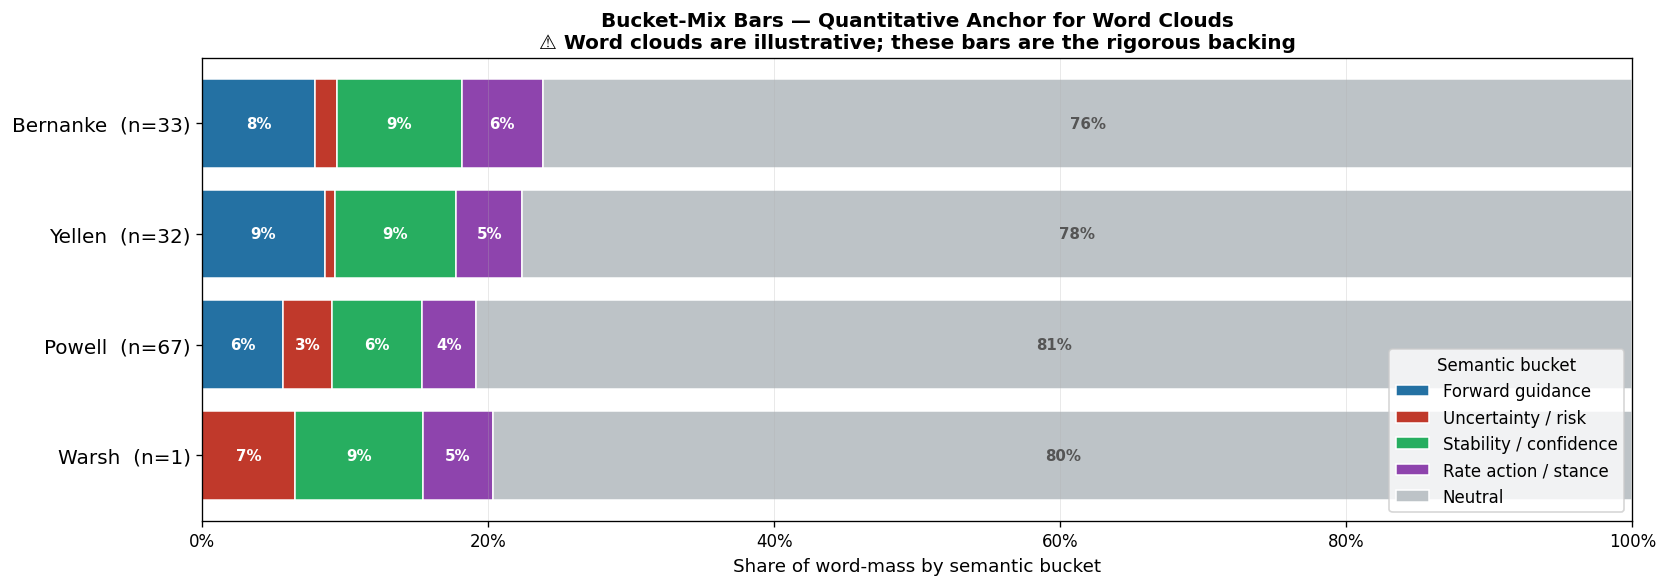

In [42]:

def compute_bucket_mix(freq_table: dict[str, float]) -> dict[str, float]:
    """Proportion of total word-mass falling in each semantic bucket."""
    totals = {b: 0.0 for b in BUCKET_COLORS}
    grand  = 0.0
    for word, freq in freq_table.items():
        b       = classify_word(word)
        totals[b] += freq
        grand     += freq
    if grand == 0:
        return {b: 0.0 for b in totals}
    return {b: totals[b] / grand for b in totals}


def plot_bucket_bars(freq_tables: dict) -> plt.Figure:
    """
    Layout C — horizontal stacked bars.
    One row per chair; segments show % of word-mass in each bucket.
    This is the QUANTITATIVE anchor — numbers behind the word clouds.
    """
    buckets = ["guidance", "uncertainty", "stability", "action", "neutral"]
    mixes   = {c: compute_bucket_mix(freq_tables[c]) for c in CHAIRS}

    fig, ax = plt.subplots(figsize=(14, 5))
    y_pos   = np.arange(len(CHAIRS))
    left    = np.zeros(len(CHAIRS))

    for bucket in buckets:
        vals = np.array([mixes[c][bucket] for c in CHAIRS])
        ax.barh(y_pos, vals, left=left,
                color=BUCKET_COLORS[bucket], label=BUCKET_DISPLAY[bucket],
                edgecolor="white", linewidth=0.9)
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 0.025:
                ax.text(l + v / 2, i, f"{v:.0%}",
                        ha="center", va="center", fontsize=9, fontweight="bold",
                        color="white" if bucket != "neutral" else "#555")
        left += vals

    n_stmts = [
        len(_wc_docs[(_wc_docs["doc_type"]=="statement") & (_wc_docs["chair"]==c)])
        for c in CHAIRS
    ]
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f"{c}  (n={n})" for c, n in zip(CHAIRS, n_stmts)], fontsize=12)
    ax.set_xlabel("Share of word-mass by semantic bucket", fontsize=11)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title(
        "Bucket-Mix Bars — Quantitative Anchor for Word Clouds\n"
        "⚠ Word clouds are illustrative; these bars are the rigorous backing",
        fontsize=12, fontweight="bold",
    )
    ax.legend(loc="lower right", fontsize=10,
              title="Semantic bucket", title_fontsize=10)
    ax.grid(axis="x", lw=0.4, alpha=0.4)
    ax.invert_yaxis()
    fig.tight_layout()
    savefig(fig, "fig7c_bucket_bars")
    return fig


fig7c = plot_bucket_bars(freq_tables)
plt.show()

In [43]:

def build_word_table(freq_tables: dict, tfidf_scores: dict,
                     top_n: int = 40) -> pd.DataFrame:
    """Top-N words per chair with bucket, raw frequency, and TF-IDF score."""
    rows = []
    for chair in CHAIRS:
        ft, ti = freq_tables.get(chair, {}), tfidf_scores.get(chair, {})
        top    = sorted(ft.items(), key=lambda x: ti.get(x[0], 0), reverse=True)[:top_n]
        for word, freq in top:
            rows.append({
                "chair":    chair,
                "word":     word,
                "bucket":   classify_word(word),
                "freq":     round(freq, 4),
                "tfidf":    round(ti.get(word, 0), 4),
            })
    return pd.DataFrame(rows)


def export_html_table(word_df: pd.DataFrame,
                      out: Path = VIZ_OUT / "fig7d_interactive.html") -> Path:
    """
    Colour-coded, sortable HTML table.
    Word  ·  Bucket (colour-highlighted)  ·  Frequency  ·  TF-IDF
    """
    rows_html = []
    for _, r in word_df.iterrows():
        bg   = BUCKET_COLORS.get(r["bucket"], "#bdc3c7")
        fg   = "white" if r["bucket"] != "neutral" else "#555"
        rows_html.append(
            f'<tr>'
            f'<td style="color:{_CHAIR_COLORS.get(r["chair"],"#333")};font-weight:bold">{r["chair"]}</td>'
            f'<td><b>{r["word"]}</b></td>'
            f'<td style="background:{bg};color:{fg};text-align:center;border-radius:4px">'
            f'{BUCKET_DISPLAY.get(r["bucket"],r["bucket"])}</td>'
            f'<td style="text-align:right">{r["freq"]:.4f}</td>'
            f'<td style="text-align:right">{r["tfidf"]:.4f}</td>'
            f'</tr>'
        )
    legend_html = "  ".join(
        f'<span style="background:{BUCKET_COLORS[b]};color:white;'
        f'padding:2px 8px;border-radius:3px;font-size:0.85em">'
        f'{BUCKET_DISPLAY[b]}</span>'
        for b in ["guidance", "uncertainty", "stability", "action", "neutral"]
    )
    html = f"""<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8">
<title>FOMC Chair Word Table</title>
<style>
  body{{font-family:system-ui,sans-serif;padding:24px;background:#f7f9fc;color:#222}}
  h2{{color:#2c3e50;margin-bottom:4px}}
  .legend{{margin:8px 0 16px}}
  table{{border-collapse:collapse;width:100%;background:white;
         box-shadow:0 1px 6px rgba(0,0,0,.1);border-radius:6px;overflow:hidden}}
  th{{background:#2c3e50;color:white;padding:10px 14px;text-align:left;
      cursor:pointer;user-select:none}}
  th:hover{{background:#34495e}}
  td{{padding:8px 14px;border-bottom:1px solid #eee}}
  tr:hover td{{background:#eef4fb}}
  .caveat{{color:#888;font-size:0.83em;margin-top:14px}}
</style>
<script>
let _asc={{}};
function sort(col){{
  const tb=document.querySelector('tbody');
  const rows=[...tb.rows];
  _asc[col]=!_asc[col];
  rows.sort((a,b)=>{{
    const va=a.cells[col].innerText, vb=b.cells[col].innerText;
    return _asc[col]
      ? va.localeCompare(vb,undefined,{{numeric:true}})
      : vb.localeCompare(va,undefined,{{numeric:true}});
  }});
  rows.forEach(r=>tb.appendChild(r));
}}
</script></head><body>
<h2>FOMC Chair Word Table — Semantic Bucket Analysis</h2>
<div class="legend">{legend_html}</div>
<table>
<thead><tr>
  <th onclick="sort(0)">Chair ▲▼</th>
  <th onclick="sort(1)">Word ▲▼</th>
  <th onclick="sort(2)">Bucket ▲▼</th>
  <th onclick="sort(3)">Freq ▲▼</th>
  <th onclick="sort(4)">TF-IDF ▲▼</th>
</tr></thead>
<tbody>{"".join(rows_html)}</tbody>
</table>
<p class="caveat">⚠ Word clouds are an illustrative exhibit.
The bucket-mix bars (Fig 7c) and regression tables (Layer 4)
are the rigorous statistical backing.  TF-IDF computed across
{len(CHAIRS)} chair-corpora; Warsh N=1 statement — treat as illustrative.</p>
</body></html>"""
    out.write_text(html, encoding="utf-8")
    print(f"  Saved → {out}")
    return out


_word_table = build_word_table(freq_tables, tfidf_scores, top_n=40)
try:
    from IPython.display import display
    display(_word_table.head(20))
except ImportError:
    print(_word_table.head(20).to_string(index=False))

_html_path = export_html_table(_word_table)
print(f"\nOpen {_html_path.name} in a browser or VS Code Live Preview for hover/sort.")

,chair,word,bucket,freq,tfidf
0,Bernanke,resource,neutral,0.2452,0.0889
1,Bernanke,exceptionally,neutral,0.2129,0.0862
2,Bernanke,subdued,neutral,0.2065,0.0856
3,Bernanke,depressed,neutral,0.1419,0.0784
4,Bernanke,particular,neutral,0.1161,0.0745
5,Bernanke,securities,neutral,1.0000,0.0739
6,Bernanke,composition,neutral,0.1097,0.0735
7,Bernanke,years,neutral,0.1032,0.0723
8,Bernanke,stable,stability,0.2839,0.0723
9,Bernanke,housing,neutral,0.2774,0.0719


  Saved → fomc_viz/fig7d_interactive.html

Open fig7d_interactive.html in a browser or VS Code Live Preview for hover/sort.


In [44]:

def warsh_readout(freq_tables: dict, tfidf_scores: dict,
                  chair_b: str = "Warsh", top_n: int = 12) -> None:
    """
    Structured comparison: Warsh vs. Bernanke / Yellen / Powell on
    corpus size, bucket-mix, and most distinctive TF-IDF words.
    Concludes with a plain-language thesis check.
    """
    n_by_chair = {
        c: len(_wc_docs[(_wc_docs["doc_type"] == "statement") & (_wc_docs["chair"] == c)])
        for c in CHAIRS
    }
    mixes   = {c: compute_bucket_mix(freq_tables[c]) for c in CHAIRS}
    others  = [c for c in CHAIRS if c != chair_b]
    buckets = ["guidance", "uncertainty", "stability", "action", "neutral"]

    print("═" * 68)
    print(f"  WARSH READOUT — Vol-Through-Text Thesis Check")
    print(f"  (Warsh vs. {' / '.join(others)})")
    print("═" * 68)

    # 1. Corpus size
    print("\n  1. CORPUS SIZE")
    for c in CHAIRS:
        marker = " ◄ Warsh" if c == chair_b else ""
        nw     = len(freq_tables.get(c, {}))
        print(f"     {c:12s}: {n_by_chair[c]:3d} statements  {nw:5d} unique tokens{marker}")

    # 2. Bucket-mix table
    print("\n  2. BUCKET-MIX  (% word-mass in each bucket)")
    col_w = 13
    print("     " + f"{'Bucket':17s}" +
          "".join(f"{c:>{col_w}s}" for c in CHAIRS) +
          f"  {'Others avg':>11s}")
    print("     " + "─" * (17 + col_w * len(CHAIRS) + 14))
    for b in buckets:
        warsh_v    = mixes[chair_b][b]
        others_avg = np.mean([mixes[c][b] for c in others])
        flag       = " ◄ DIVERGES" if abs(warsh_v - others_avg) > 0.05 else ""
        row = f"     {b:17s}" + \
              "".join(f"{mixes[c][b]*100:>{col_w}.1f}%" for c in CHAIRS) + \
              f"  {others_avg*100:>10.1f}%{flag}"
        print(row)

    # 3. Top TF-IDF words for Warsh
    print(f"\n  3. WARSH'S TOP {top_n} DISTINCTIVE WORDS  (by TF-IDF score)")
    warsh_tfidf = sorted(tfidf_scores.get(chair_b, {}).items(),
                          key=lambda x: x[1], reverse=True)[:top_n]
    for word, score in warsh_tfidf:
        bucket = classify_word(word)
        print(f"     {word:30s}  TF-IDF={score:.4f}  [{bucket}]")

    # 4. Thesis check
    warsh_mix  = mixes[chair_b]
    others_avg = {b: np.mean([mixes[c][b] for c in others]) for b in buckets}
    sparser    = n_by_chair[chair_b] < np.mean([n_by_chair[c] for c in others])
    more_unc   = warsh_mix["uncertainty"]  > others_avg["uncertainty"]
    less_guid  = warsh_mix["guidance"]     < others_avg["guidance"]
    verdict    = "CONSISTENT" if (more_unc or less_guid) else "NOT YET SUPPORTED"

    print("\n  4. THESIS CHECK")
    print(f"     Cloud sparser (fewer statements)?  {'YES' if sparser else 'NO '}"
          f"  Warsh={n_by_chair[chair_b]}  others_avg="
          f"{np.mean([n_by_chair[c] for c in others]):.1f}")
    print(f"     Higher uncertainty word-mass?      {'YES ◄' if more_unc else 'NO  '}"
          f"  Warsh={warsh_mix['uncertainty']:.1%}  others_avg={others_avg['uncertainty']:.1%}")
    print(f"     Lower guidance word-mass?          {'YES ◄' if less_guid else 'NO  '}"
          f"  Warsh={warsh_mix['guidance']:.1%}  others_avg={others_avg['guidance']:.1%}")
    print(f"\n     Verdict: cloud pattern is {verdict} with the vol-through-text thesis.")
    print(f"\n  ⚠  Caveat: Warsh has {n_by_chair[chair_b]} statement(s).")
    print("     Word clouds are illustrative; bucket-mix bars + Layer 4 regressions")
    print("     are the rigorous statistical backing.")
    print("═" * 68)


warsh_readout(freq_tables, tfidf_scores)

════════════════════════════════════════════════════════════════════
  WARSH READOUT — Vol-Through-Text Thesis Check
  (Warsh vs. Bernanke / Yellen / Powell)
════════════════════════════════════════════════════════════════════

  1. CORPUS SIZE
     Bernanke    :  33 statements   2032 unique tokens
     Yellen      :  32 statements   1700 unique tokens
     Powell      :  67 statements   2127 unique tokens
     Warsh       :   1 statements    119 unique tokens ◄ Warsh

  2. BUCKET-MIX  (% word-mass in each bucket)
     Bucket                Bernanke       Yellen       Powell        Warsh   Others avg
     ───────────────────────────────────────────────────────────────────────────────────
     guidance                   7.9%          8.6%          5.6%          0.0%         7.3% ◄ DIVERGES
     uncertainty                1.5%          0.7%          3.5%          6.5%         1.9%
     stability                  8.7%          8.5%          6.3%          8.9%         7.9%
     action     

---
# LAYER 7 — WORD-VOL CORRELATION & WARSH BACKTEST

**Goal:** find which specific words in Fed statements correlate with realized
volatility, then use that signal to backtest whether Warsh's June 2026 language
predicted the elevated event-day vol he delivered.

**Training universe:** 132 historical meetings (Bernanke / Yellen / Powell).
**Out-of-sample test:** Warsh June 17, 2026 — 1 meeting, truly held-out.

| Output | What it shows |
|--------|---------------|
| Fig 8a | Top-40 word–GK vol correlations (bar chart, colour = bucket) |
| Fig 8b | NLP feature × vol metric correlation heatmap |
| Fig 8c | Ridge-predicted vs actual vol; Warsh backtest annotated |
| Readout | Top signal words from Warsh's statement; predicted vs actual |

In [45]:

from sklearn.feature_extraction.text import TfidfVectorizer as _TfidfVecL7
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr as _pearsonr

_VOL_TARGETS = [c for c in ["gk_vol_10y", "rv_yield_10y_5d", "rv_yield_10y_10d"]
                if c in master.columns]


def _build_word_vol_matrix(docs_df: pd.DataFrame,
                           master_df: pd.DataFrame,
                           min_df: int = 5,
                           max_features: int = 1200) -> tuple:
    """
    Align statement text with vol targets, vectorize to TF-IDF.

    Returns
    -------
    X_df        : DataFrame (n_meetings × vocab), TF-IDF weights
    vol_df      : DataFrame (n_meetings × vol_targets)
    chairs      : Series aligned to rows
    vectorizer  : fitted TfidfVectorizer
    """
    stmt = (docs_df[docs_df["doc_type"] == "statement"][["meeting_date", "text"]]
            .copy())
    stmt["meeting_date"] = pd.to_datetime(stmt["meeting_date"])

    m = master_df[["meeting_date", "chair"] + _VOL_TARGETS].copy()
    m["meeting_date"] = pd.to_datetime(m["meeting_date"])
    merged = stmt.merge(m, on="meeting_date", how="inner").sort_values("meeting_date")

    vec = _TfidfVecL7(
        preprocessor=_clean,
        tokenizer=lambda t: _tokenise(t, bigrams=False),
        token_pattern=None,
        min_df=min_df,
        max_features=max_features,
        sublinear_tf=True,
        ngram_range=(1, 2),   # include bigrams for phrases
    )
    X_sp = vec.fit_transform(merged["text"].fillna(""))
    X_df = pd.DataFrame(X_sp.toarray(),
                        columns=vec.get_feature_names_out(),
                        index=pd.to_datetime(merged["meeting_date"].values))
    vol_df = merged[["meeting_date"] + _VOL_TARGETS].set_index(
        pd.to_datetime(merged["meeting_date"].values))
    chairs = merged.set_index(
        pd.to_datetime(merged["meeting_date"].values))["chair"]
    return X_df, vol_df, chairs, vec


def _word_vol_corrs(X_df: pd.DataFrame, y: pd.Series,
                    min_meetings: int = 5) -> pd.DataFrame:
    """Pearson r between each word's TF-IDF weight and y across meetings."""
    common = X_df.index.intersection(y.dropna().index)
    Xs, ys = X_df.loc[common], y.loc[common]
    rows = []
    for word in Xs.columns:
        x = Xs[word].values
        if (x > 0).sum() < min_meetings:
            continue
        r, p = _pearsonr(x, ys.values)
        rows.append({"word": word, "r": r, "p": p,
                     "bucket": classify_word(word),
                     "n": int((x > 0).sum())})
    return (pd.DataFrame(rows)
              .assign(abs_r=lambda d: d["r"].abs())
              .sort_values("abs_r", ascending=False)
              .reset_index(drop=True))


# Build matrix
X_df, vol_df, chairs, _vec7 = _build_word_vol_matrix(_wc_docs, master)

_hist_mask  = chairs != "Warsh"
_warsh_mask = chairs == "Warsh"
X_hist      = X_df[_hist_mask]
X_warsh     = X_df[_warsh_mask]
vol_hist     = vol_df[_hist_mask]
vol_warsh    = vol_df[_warsh_mask]

print(f"Matrix: {X_df.shape}  vocab  |  historical={_hist_mask.sum()}  warsh={_warsh_mask.sum()}")
print(f"Vol targets: {_VOL_TARGETS}")

Matrix: (133, 1200)  vocab  |  historical=132  warsh=1
Vol targets: ['gk_vol_10y', 'rv_yield_10y_5d', 'rv_yield_10y_10d']


  Saved → fomc_viz/fig8a_word_vol_corr.png


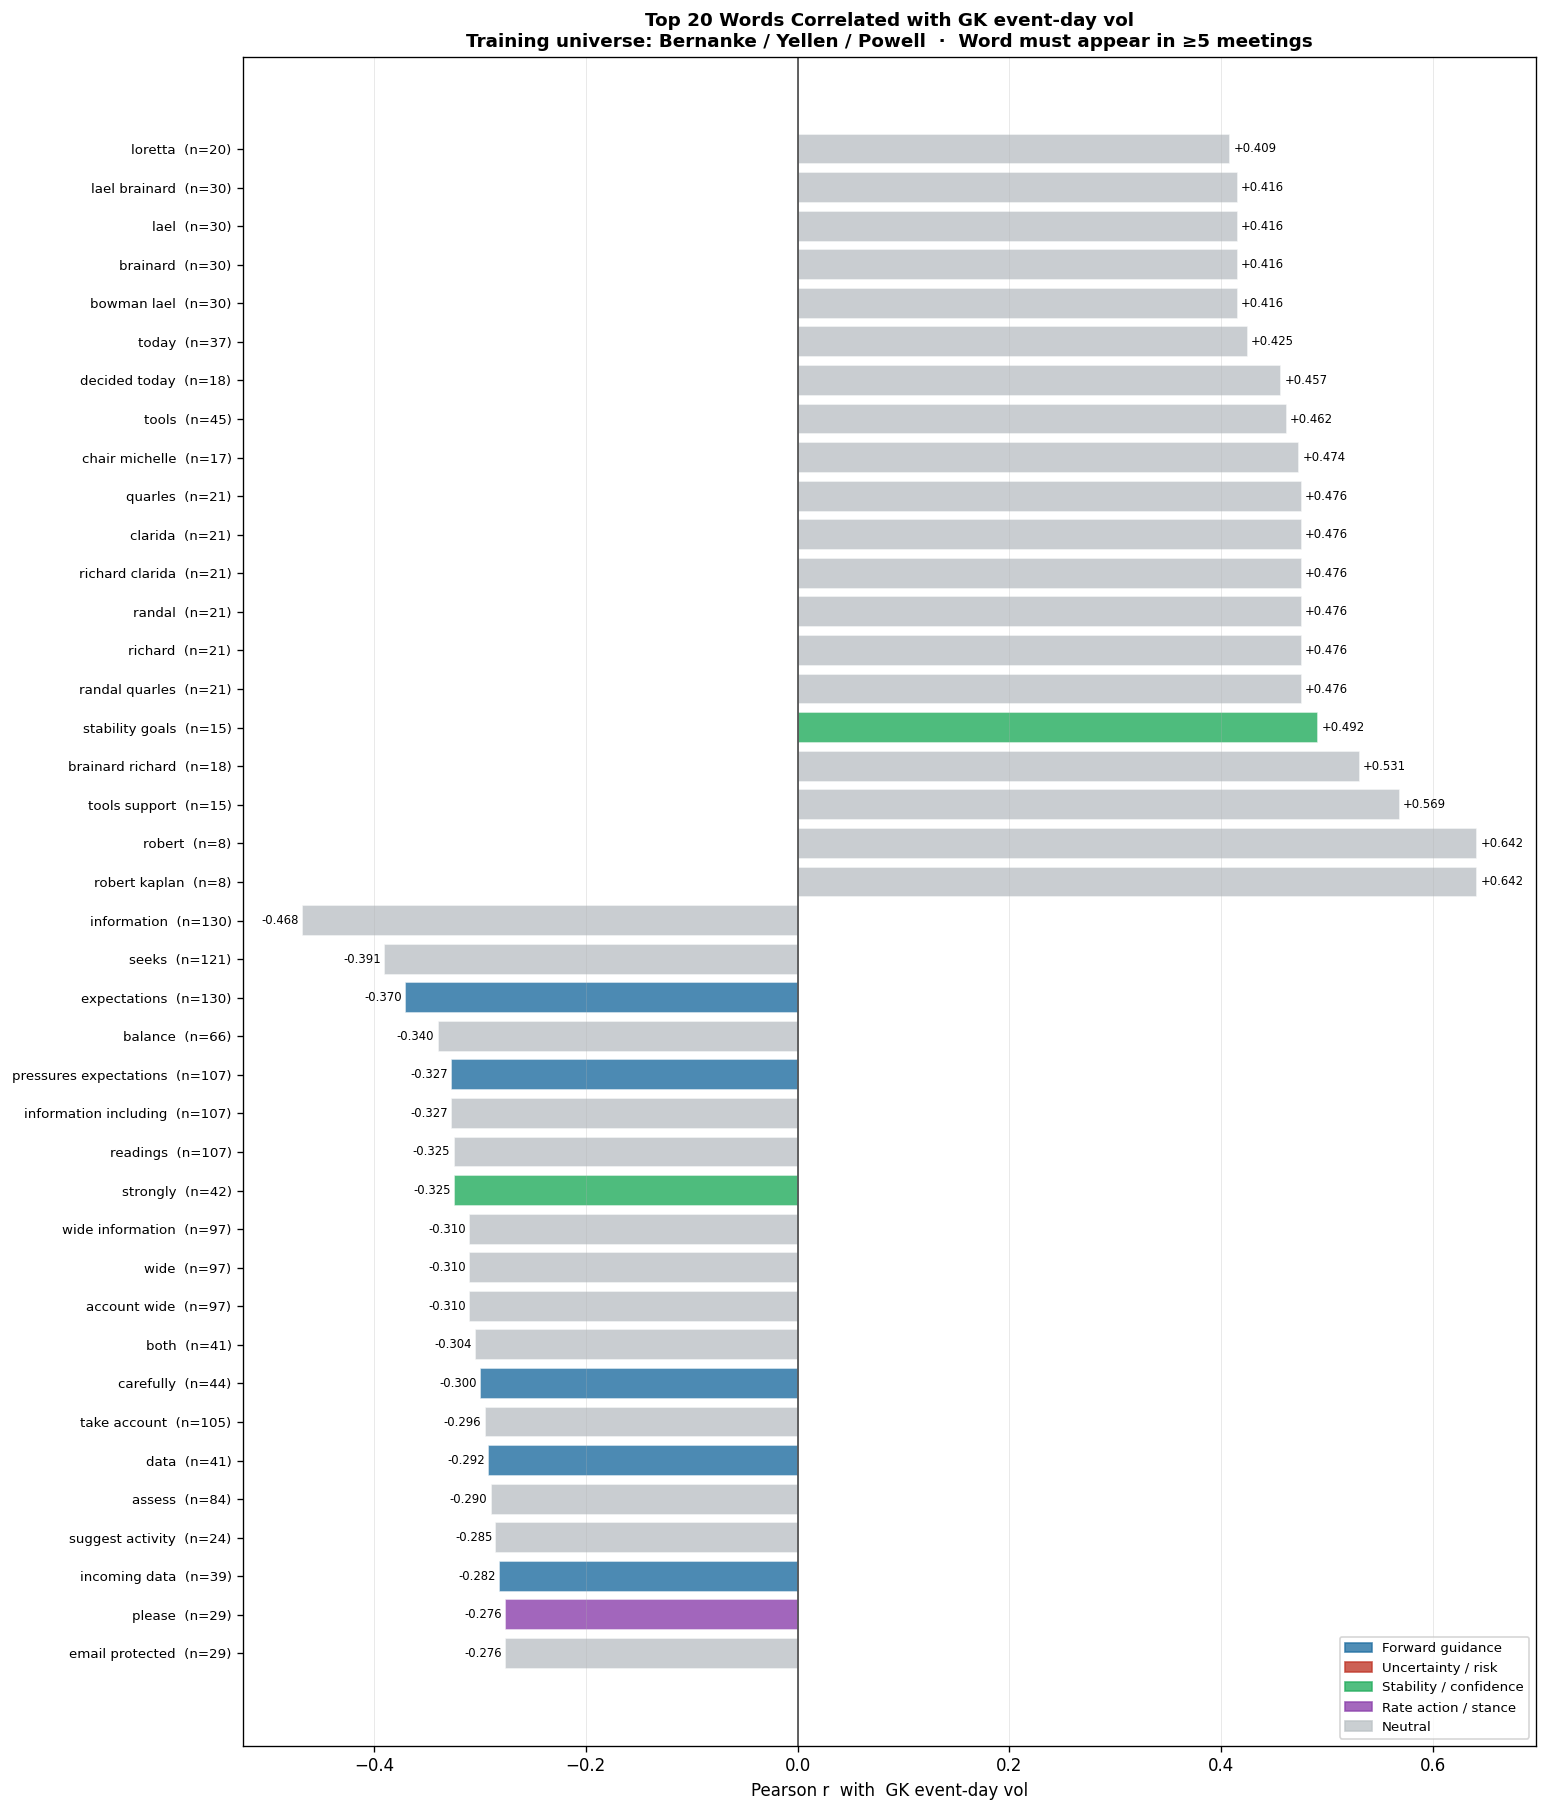


Top 10 HIGH-vol words:
            word        r            p    bucket  n
   robert kaplan 0.641788 1.458113e-16   neutral  8
          robert 0.641788 1.458113e-16   neutral  8
   tools support 0.568885 1.351988e-12   neutral 15
brainard richard 0.530895 6.896124e-11   neutral 18
 stability goals 0.491726 2.457563e-09 stability 15
  randal quarles 0.476268 8.932994e-09   neutral 21
         richard 0.476268 8.932994e-09   neutral 21
          randal 0.476268 8.932994e-09   neutral 21
 richard clarida 0.476268 8.932994e-09   neutral 21
         clarida 0.476268 8.932994e-09   neutral 21

Top 10 LOW-vol words:
                  word         r            p    bucket   n
           information -0.467944 1.743792e-08   neutral 130
                 seeks -0.390582 3.985736e-06   neutral 121
          expectations -0.370291 1.340813e-05  guidance 130
               balance -0.339936 7.114789e-05   neutral  66
pressures expectations -0.327193 1.364357e-04  guidance 107
 information includin

In [46]:

def plot_word_vol_corr(corr_df: pd.DataFrame,
                       vol_label: str = "GK event-day vol",
                       top_n: int = 20) -> plt.Figure:
    """
    Diverging bar chart: top_n high-vol words (right, red shades) and
    top_n low-vol words (left, blue shades), coloured by semantic bucket.
    """
    pos = corr_df[corr_df["r"] > 0].head(top_n)
    neg = corr_df[corr_df["r"] < 0].head(top_n)
    plot_df = pd.concat([neg.iloc[::-1], pos]).reset_index(drop=True)

    colors = [BUCKET_COLORS.get(b, "#bdc3c7") for b in plot_df["bucket"]]
    y_pos  = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(13, max(8, len(plot_df) * 0.38)))
    bars = ax.barh(y_pos, plot_df["r"], color=colors, alpha=0.82, edgecolor="white")

    ax.axvline(0, color="#333333", lw=0.9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(
        [f"{r['word']}  (n={r['n']})" for _, r in plot_df.iterrows()],
        fontsize=8,
    )
    ax.set_xlabel(f"Pearson r  with  {vol_label}", fontsize=10)
    ax.set_title(
        f"Top {top_n} Words Correlated with {vol_label}\n"
        "Training universe: Bernanke / Yellen / Powell  ·  "
        "Word must appear in ≥5 meetings",
        fontsize=11, fontweight="bold",
    )

    # Annotate r values on bars
    for bar, r_val in zip(bars, plot_df["r"]):
        x = bar.get_width()
        ax.text(x + (0.003 if x >= 0 else -0.003), bar.get_y() + bar.get_height() / 2,
                f"{r_val:+.3f}", va="center",
                ha="left" if x >= 0 else "right", fontsize=7)

    # Legend
    handles = [mpatches.Patch(color=BUCKET_COLORS[b], alpha=0.8, label=BUCKET_DISPLAY[b])
               for b in ["guidance", "uncertainty", "stability", "action", "neutral"]]
    ax.legend(handles=handles, fontsize=8, loc="lower right")
    ax.grid(axis="x", lw=0.4, alpha=0.4)
    fig.tight_layout()
    savefig(fig, "fig8a_word_vol_corr")
    return fig


_corrs_gk = _word_vol_corrs(X_hist, vol_hist["gk_vol_10y"]) if "gk_vol_10y" in vol_hist else pd.DataFrame()
if not _corrs_gk.empty:
    fig8a = plot_word_vol_corr(_corrs_gk, vol_label="GK event-day vol", top_n=20)
    plt.show()
    print(f"\nTop 10 HIGH-vol words:")
    print(_corrs_gk[_corrs_gk["r"] > 0].head(10)[["word","r","p","bucket","n"]].to_string(index=False))
    print(f"\nTop 10 LOW-vol words:")
    print(_corrs_gk[_corrs_gk["r"] < 0].head(10)[["word","r","p","bucket","n"]].to_string(index=False))

  Saved → fomc_viz/fig8b_feature_vol_heatmap.png


/var/folders/bq/x0_jcxf116d1_ftpxqt7c4_80000gn/T/ipykernel_9309/636008355.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = _pearsonr(valid[f], valid[v])
/var/folders/bq/x0_jcxf116d1_ftpxqt7c4_80000gn/T/ipykernel_9309/636008355.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = _pearsonr(valid[f], valid[v])
/var/folders/bq/x0_jcxf116d1_ftpxqt7c4_80000gn/T/ipykernel_9309/636008355.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = _pearsonr(valid[f], valid[v])


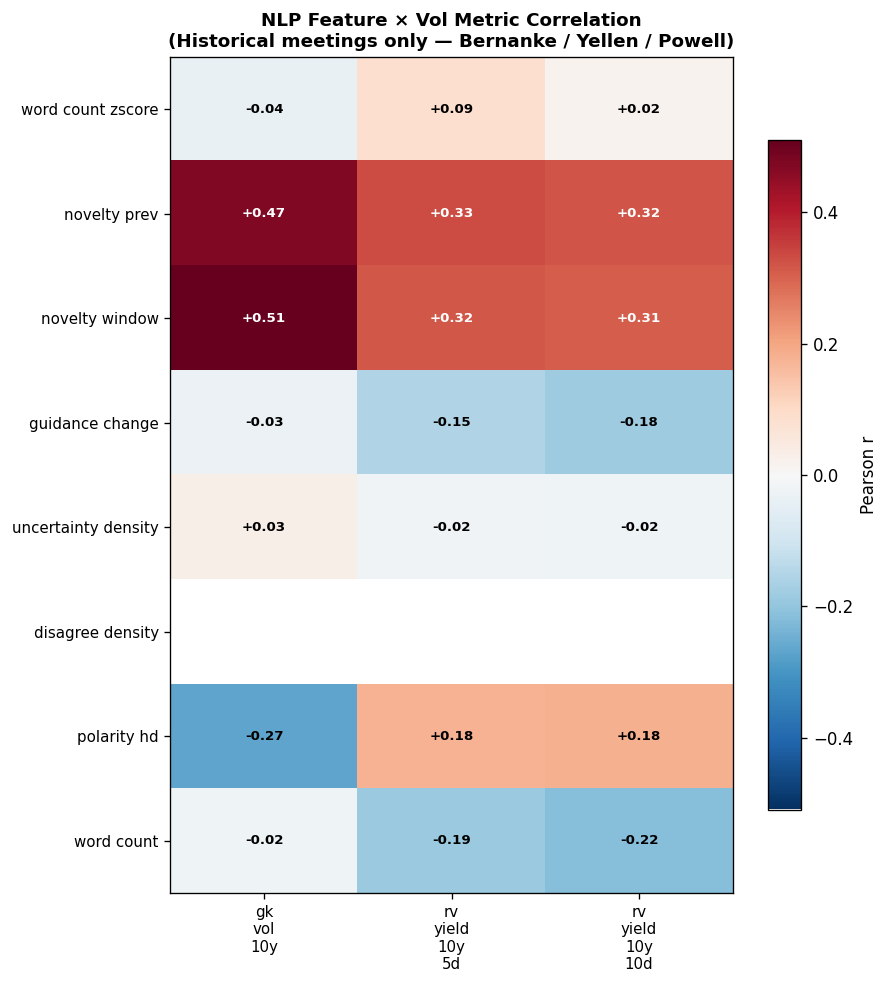

In [47]:

def plot_feature_vol_heatmap(master_df: pd.DataFrame) -> plt.Figure:
    """
    Pearson correlation matrix: NLP features (rows) × vol metrics (cols).
    Diverging palette centred at zero; annotated with r values.
    Historical meetings only (Warsh excluded so Warsh shows as OOS in Fig 8c).
    """
    feat_cols = [c for c in VOL_FEATURES + ["polarity_hd", "word_count"]
                 if c in master_df.columns]
    vol_cols  = [c for c in _VOL_TARGETS if c in master_df.columns]

    sub = master_df[master_df["chair"] != "Warsh"][feat_cols + vol_cols].dropna(how="all")

    # Build corr matrix manually
    mat = pd.DataFrame(index=feat_cols, columns=vol_cols, dtype=float)
    for f in feat_cols:
        for v in vol_cols:
            valid = sub[[f, v]].dropna()
            if len(valid) > 5:
                r, _ = _pearsonr(valid[f], valid[v])
                mat.loc[f, v] = r
            else:
                mat.loc[f, v] = np.nan

    fig, ax = plt.subplots(figsize=(max(6, len(vol_cols) * 2.5), len(feat_cols) * 0.85 + 1.5))
    vabs = np.nanmax(np.abs(mat.values.astype(float)))
    im   = ax.imshow(mat.values.astype(float), cmap="RdBu_r",
                     vmin=-vabs, vmax=vabs, aspect="auto")
    plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.8)

    ax.set_xticks(range(len(vol_cols)))
    ax.set_xticklabels([c.replace("_", "\n") for c in vol_cols], fontsize=9)
    ax.set_yticks(range(len(feat_cols)))
    ax.set_yticklabels([c.replace("_", " ") for c in feat_cols], fontsize=9)

    for i, f in enumerate(feat_cols):
        for j, v in enumerate(vol_cols):
            val = mat.loc[f, v]
            if not np.isnan(val):
                ax.text(j, i, f"{val:+.2f}", ha="center", va="center",
                        fontsize=8, fontweight="bold",
                        color="white" if abs(val) > 0.3 else "black")

    ax.set_title("NLP Feature × Vol Metric Correlation\n"
                 "(Historical meetings only — Bernanke / Yellen / Powell)",
                 fontsize=11, fontweight="bold")
    fig.tight_layout()
    savefig(fig, "fig8b_feature_vol_heatmap")
    return fig


fig8b = plot_feature_vol_heatmap(master)
plt.show()

In [48]:

def fit_ridge_model(X_train: pd.DataFrame,
                    y_train: pd.Series,
                    alpha: float = 50.0) -> tuple:
    """
    Ridge regression on TF-IDF word matrix.
    alpha=50 provides strong regularisation given n≈130, p≈1200.
    Returns (fitted_model, scaler, cv_predictions, cv_r2).
    """
    valid = y_train.dropna()
    Xv    = X_train.loc[valid.index]
    yv    = valid.values

    scaler = StandardScaler(with_mean=False)
    Xs     = scaler.fit_transform(Xv)

    model  = Ridge(alpha=alpha)
    cv     = KFold(n_splits=5, shuffle=True, random_state=42)
    y_cv   = cross_val_predict(model, Xs, yv, cv=cv)
    cv_r2  = r2_score(yv, y_cv)
    cv_mae = mean_absolute_error(yv, y_cv)

    model.fit(Xs, yv)   # refit on full training set
    print(f"Ridge (α={alpha})  5-fold CV  R²={cv_r2:.3f}  MAE={cv_mae:.3f}pp")
    return model, scaler, pd.Series(y_cv, index=valid.index), cv_r2


def predict_warsh(model, scaler, X_warsh: pd.DataFrame,
                  vec: _TfidfVecL7, top_n: int = 10) -> tuple:
    """
    Predict vol for each Warsh meeting.
    Also returns top contributing words (coef × feature value).
    """
    if X_warsh.empty:
        return pd.Series(dtype=float), {}

    Xs    = scaler.transform(X_warsh)
    preds = model.predict(Xs)
    pred_s = pd.Series(preds, index=X_warsh.index)

    # Top word contributions for most recent Warsh meeting
    feat_vals = X_warsh.iloc[-1].values
    contribs  = model.coef_ * scaler.scale_**-1 * feat_vals
    word_contrib = dict(zip(X_warsh.columns, contribs))
    top_words = sorted(word_contrib.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]

    return pred_s, dict(top_words)


# Fit on historical GK vol
_y_gk_hist = vol_hist["gk_vol_10y"] if "gk_vol_10y" in vol_hist else pd.Series(dtype=float)

if not _y_gk_hist.dropna().empty:
    _ridge, _scaler, _cv_preds, _cv_r2 = fit_ridge_model(X_hist, _y_gk_hist)
    _warsh_preds, _warsh_contribs       = predict_warsh(_ridge, _scaler, X_warsh, _vec7)
else:
    _cv_preds, _warsh_preds, _warsh_contribs = pd.Series(dtype=float), pd.Series(dtype=float), {}

Ridge (α=50.0)  5-fold CV  R²=0.212  MAE=12.897pp


  Saved → fomc_viz/fig8c_warsh_backtest.png


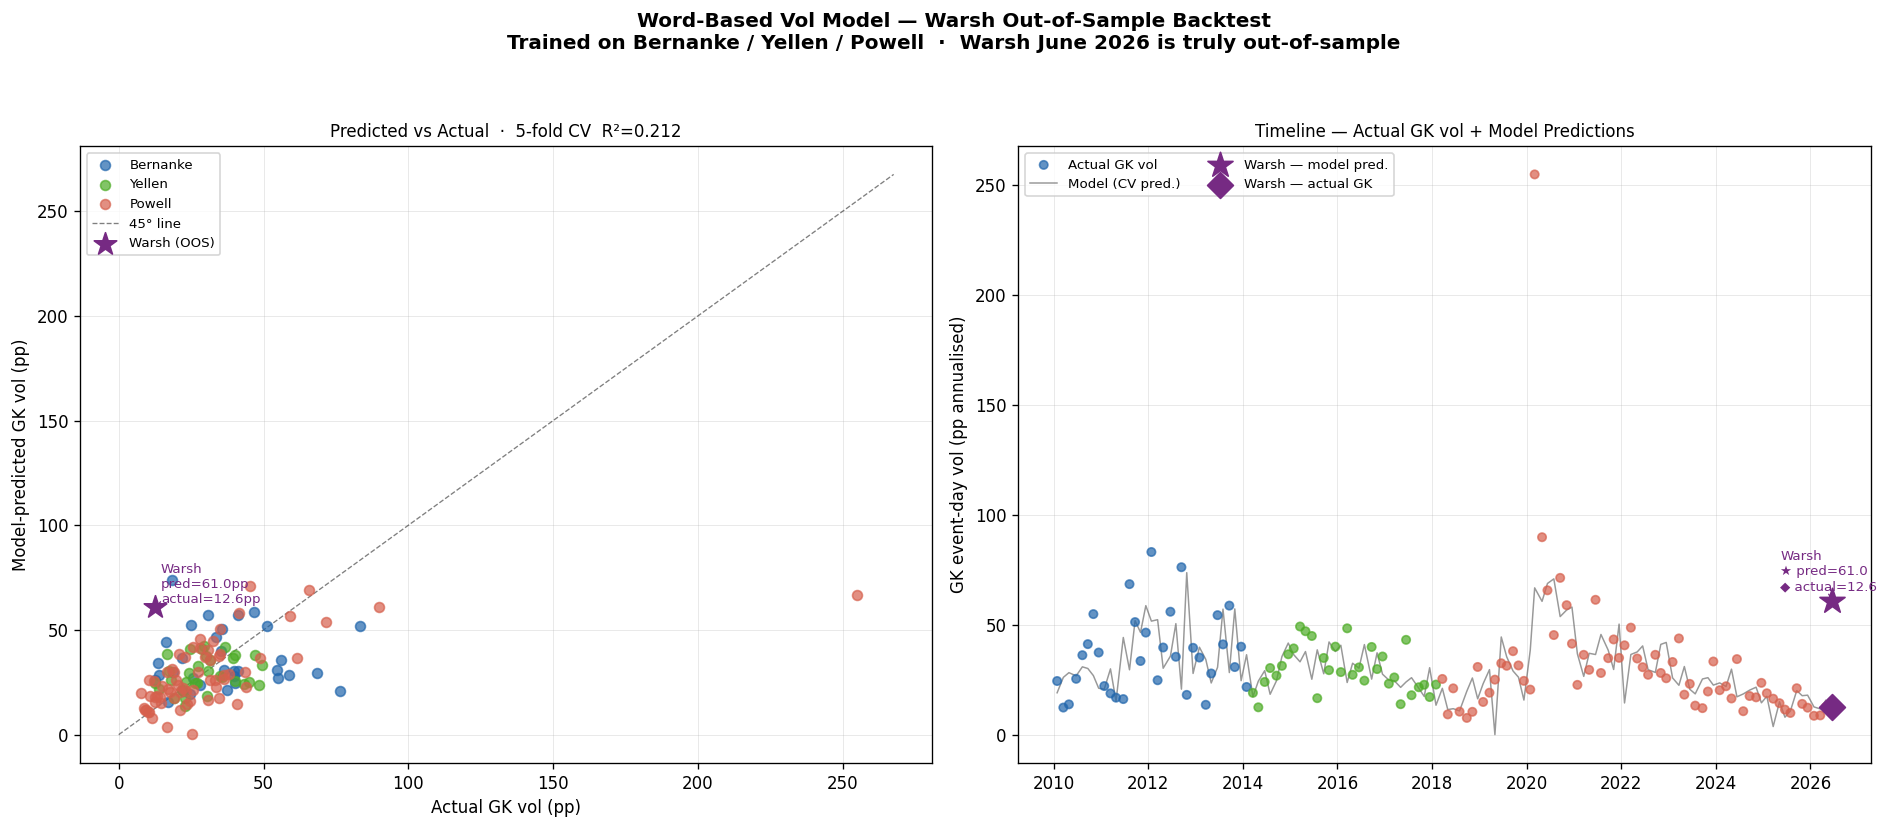

In [49]:

def plot_warsh_backtest(cv_preds: pd.Series,
                        y_actual: pd.Series,
                        warsh_preds: pd.Series,
                        vol_warsh_actual: pd.Series,
                        chairs: pd.Series) -> plt.Figure:
    """
    Two-panel backtest figure.

    Left: Scatter of 5-fold CV predicted vs actual vol (historical).
          Colour = chair. Warsh prediction overlaid as a star.
    Right: Timeline — actual GK vol (dots) + model prediction (line),
           Warsh meeting starred and labelled.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Word-Based Vol Model — Warsh Out-of-Sample Backtest\n"
                 "Trained on Bernanke / Yellen / Powell  ·  "
                 "Warsh June 2026 is truly out-of-sample",
                 fontsize=12, fontweight="bold")

    # ── Left: predicted vs actual scatter ────────────────────────────────────
    common = cv_preds.index.intersection(y_actual.dropna().index)
    if len(common):
        yp  = cv_preds.loc[common]
        ya  = y_actual.loc[common]
        ch  = chairs.loc[common] if common[0] in chairs.index else pd.Series("Unknown", index=common)

        for chair in ["Bernanke", "Yellen", "Powell"]:
            m = ch == chair
            ax1.scatter(ya[m], yp[m], color=_CHAIR_COLORS.get(chair, "#888"),
                        alpha=0.7, s=35, label=chair, zorder=3)

        lim = max(ya.max(), yp.max()) * 1.05
        ax1.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5, label="45° line")

    # Warsh prediction
    if not warsh_preds.empty:
        for date, pred in warsh_preds.items():
            actual = float(vol_warsh_actual.loc[date]) if date in vol_warsh_actual.index and not pd.isna(vol_warsh_actual.loc[date]) else None
            if actual is not None:
                ax1.scatter([actual], [pred], color=_CHAIR_COLORS.get("Warsh","#762a83"),
                            s=200, marker="*", zorder=6, label=f"Warsh (OOS)")
                ax1.annotate(f"Warsh\npred={pred:.1f}pp\nactual={actual:.1f}pp",
                             xy=(actual, pred), xytext=(actual + 2, pred + 2),
                             fontsize=8, color=_CHAIR_COLORS.get("Warsh","#762a83"),
                             arrowprops=dict(arrowstyle="->", color="#762a83", lw=0.8))

    ax1.set_xlabel("Actual GK vol (pp)", fontsize=10)
    ax1.set_ylabel("Model-predicted GK vol (pp)", fontsize=10)
    ax1.set_title(f"Predicted vs Actual  ·  5-fold CV  R²={_cv_r2:.3f}", fontsize=10)
    ax1.legend(fontsize=8)
    ax1.grid(lw=0.4, alpha=0.4)

    # ── Right: timeline ───────────────────────────────────────────────────────
    common2 = y_actual.dropna().index
    if len(common2):
        ax2.scatter(common2, y_actual.loc[common2],
                    color=[_CHAIR_COLORS.get(chairs.get(d,"Unknown"),"#888") for d in common2],
                    s=25, alpha=0.7, zorder=3, label="Actual GK vol")

    # CV predictions for historical
    common3 = cv_preds.index.intersection(y_actual.dropna().index)
    if len(common3):
        ax2.plot(sorted(common3),
                 [cv_preds.loc[d] for d in sorted(common3)],
                 color="#555555", lw=0.9, alpha=0.6, label="Model (CV pred.)")

    # Warsh
    if not warsh_preds.empty:
        for date, pred in warsh_preds.items():
            ax2.scatter([date], [pred], color=_CHAIR_COLORS.get("Warsh","#762a83"),
                        s=250, marker="*", zorder=7, label="Warsh — model pred.")
            actual = float(vol_warsh_actual.loc[date]) if date in vol_warsh_actual.index and not pd.isna(vol_warsh_actual.loc[date]) else None
            if actual is not None:
                ax2.scatter([date], [actual], color=_CHAIR_COLORS.get("Warsh","#762a83"),
                            s=120, marker="D", zorder=7, label="Warsh — actual GK")
                ax2.annotate(
                    f"Warsh\n★ pred={pred:.1f}\n◆ actual={actual:.1f}",
                    xy=(date, max(pred, actual)),
                    xytext=(date - pd.Timedelta(days=400), max(pred, actual) + 5),
                    fontsize=8, color=_CHAIR_COLORS.get("Warsh","#762a83"),
                    arrowprops=dict(arrowstyle="->", color="#762a83", lw=0.8),
                )

    ax2.set_ylabel("GK event-day vol (pp annualised)", fontsize=10)
    ax2.set_title("Timeline — Actual GK vol + Model Predictions", fontsize=10)
    ax2.legend(fontsize=8, ncol=2)
    ax2.grid(lw=0.4, alpha=0.4)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    savefig(fig, "fig8c_warsh_backtest")
    return fig


_vol_warsh_actual = vol_warsh["gk_vol_10y"] if "gk_vol_10y" in vol_warsh else pd.Series(dtype=float)
fig8c = plot_warsh_backtest(_cv_preds, _y_gk_hist, _warsh_preds, _vol_warsh_actual, chairs)
plt.show()

In [50]:

def warsh_vol_readout(warsh_preds: pd.Series,
                      vol_warsh_actual: pd.Series,
                      word_contribs: dict,
                      cv_r2: float) -> None:
    """
    Print the Warsh backtest verdict: top signal words, predicted vs actual vol,
    and whether the word-based signal called the direction correctly.
    """
    print("═" * 68)
    print("  WARSH VOL BACKTEST — Word-Signal Prediction Check")
    print(f"  Model: Ridge(α=50) on {X_hist.shape[1]}-word TF-IDF  "
          f"·  5-fold CV R²={cv_r2:.3f}")
    print("═" * 68)

    if warsh_preds.empty:
        print("  No Warsh meetings with data.")
        return

    for date, pred in warsh_preds.items():
        actual     = vol_warsh_actual.get(date, np.nan)
        hist_mean  = _y_gk_hist.dropna().mean()
        hist_med   = _y_gk_hist.dropna().median()

        print(f"\n  Meeting:  {pd.Timestamp(date).date()}")
        print(f"  Predicted GK vol : {pred:.2f} pp")
        print(f"  Actual GK vol    : {actual:.2f} pp" if not pd.isna(actual)
              else "  Actual GK vol    : N/A (no market data yet)")
        print(f"  Historical mean  : {hist_mean:.2f} pp  ·  median : {hist_med:.2f} pp")

        if not pd.isna(actual):
            err    = pred - actual
            pct    = abs(err) / actual * 100
            direct = "CORRECT ✓" if (pred > hist_mean) == (actual > hist_mean) else "WRONG ✗"
            print(f"  Error            : {err:+.2f} pp  ({pct:.1f}%)")
            print(f"  Direction call   : {direct}  "
                  f"(predicted {'elevated' if pred>hist_mean else 'subdued'}, "
                  f"actual {'elevated' if actual>hist_mean else 'subdued'} vol)")

    print(f"\n  Top word contributions from Warsh's statement:")
    print(f"  (coef × TF-IDF weight — positive = pushes vol forecast up)")
    print(f"  {'Word':30s}  {'Contribution':>12s}  {'Bucket':15s}")
    print(f"  {'─'*60}")
    for word, contrib in sorted(word_contribs.items(), key=lambda x: abs(x[1]), reverse=True)[:15]:
        bucket = classify_word(word)
        print(f"  {word:30s}  {contrib:>+12.5f}  {bucket}")

    print(f"\n  ⚠  Caveat: word-vol correlations estimated from N≈130 meetings.")
    print("     Ridge model is regularised but may overfit idiosyncratic patterns.")
    print("     Treat directional call as the signal — magnitude as illustrative.")
    print("═" * 68)


warsh_vol_readout(_warsh_preds, _vol_warsh_actual, _warsh_contribs, _cv_r2
                  if '_cv_r2' in dir() else 0.0)

print(f"\n{'═'*62}")
print(f"  All figures → {VIZ_OUT.resolve()}")
print(f"    fig7a_small_multiples.png   (headline 2×2 grid)")
print(f"    fig7b_comparison.png        (Powell vs Warsh split)")
print(f"    fig7c_bucket_bars.png       (quantitative anchor)")
print(f"    fig7d_interactive.html      (sortable hover table)")
print(f"    fig8a_word_vol_corr.png     (word-vol correlations)")
print(f"    fig8b_feature_vol_heatmap.png (NLP × vol heatmap)")
print(f"    fig8c_warsh_backtest.png    (Warsh OOS backtest)")
print(f"  fomc_features.parquet → {PARQUET_OUT.resolve()}")
print("═" * 62)

════════════════════════════════════════════════════════════════════
  WARSH VOL BACKTEST — Word-Signal Prediction Check
  Model: Ridge(α=50) on 1200-word TF-IDF  ·  5-fold CV R²=0.212
════════════════════════════════════════════════════════════════════

  Meeting:  2026-06-17
  Predicted GK vol : 61.03 pp
  Actual GK vol    : 12.61 pp
  Historical mean  : 32.33 pp  ·  median : 28.20 pp
  Error            : +48.43 pp  (384.2%)
  Direction call   : WRONG ✗  (predicted elevated, actual subdued vol)

  Top word contributions from Warsh's statement:
  (coef × TF-IDF weight — positive = pushes vol forecast up)
  Word                            Contribution  Bucket         
  ────────────────────────────────────────────────────────────
  including                           -8.21860  neutral
  part                                -4.72686  neutral
  elevated                            -3.80138  uncertainty
  decided maintain                    -3.51776  neutral
  expanding                     